## 1. Imports and load data

In [2]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

# import plotly.graph_objs as go
import random
# import seaborn as sns
# import warnings
# import urllib.parse


from scipy import stats
from scipy.stats import pearsonr
from wordfreq import zipf_frequency

from flow_tree_utils import (
    # generate_trajs_from_df,
    # load_test_df,
    # OBJECTS,
    steiger_z_test,
    get_matched_random_walk,
    generate_flow_tree_from_trajs,
    plot_flow_tree,
)

### Load articles, links, categories

In [3]:
### Load articles and categories
data_path = "data/wikispeedia_paths-and-graph"

# load article names
article_names = []
with open(f"{data_path}/articles.tsv") as f:
    for line in f:
        line = line.strip()
        if len(line) == 0 or line[0] == "#":
            continue

        article_names.append(line)
print(f"{len(article_names)} nodes/articles loaded.")

# load shortest paths
# TODO

# load links
column_names = ["linkSource", "linkTarget"]
edges_df = pd.read_csv(
    f"{data_path}/links.tsv",
    names=column_names,
    sep="\t",
    skiprows=[i for i in range(13)],
)
edge_dict = dict(zip(edges_df.linkSource, edges_df.linkTarget))
print(f"{np.sum([len(v) for _, v in edge_dict.items()])} edges/hyperlinks loaded.")


# load categories
def get_nth_category(category_string, n):
    category_list = category_string.split(".")
    if len(category_list) <= n:
        return pd.NA
    return category_list[n]


column_names = ["article", "category"]
categories_df = pd.read_csv(
    f"{data_path}/categories.tsv",
    names=column_names,
    sep="\t",
    skiprows=[i for i in range(13)],
)
categories_df["num_categories"] = categories_df["category"].apply(
    lambda x: len(x.split("."))
)

max_category_depth = categories_df["num_categories"].max()
print(f"Categories loaded. Max depth is {max_category_depth}.")
for i in range(categories_df["num_categories"].max()):
    categories_df[f"category{i}"] = categories_df["category"].apply(
        lambda x: get_nth_category(x, i)
    )

category_level_dict = {}
for i in range(max_category_depth):
    for cat in categories_df[f"category{i}"].dropna():
        category_level_dict[cat] = i

for _, row in categories_df.iterrows():
    category_level_dict[row["article"]] = row["num_categories"]

# edge_level_dict = {}
# for k, v in edge_dict.items():
#     if k not in category_level_dict or v not in category_level_dict:
#         continue
#     edge_level_dict[(k, v)] = category_level_dict[v] - category_level_dict[k]

4604 nodes/articles loaded.
52271 edges/hyperlinks loaded.
Categories loaded. Max depth is 4.


### Load trajectories

In [4]:
def get_nth_article(article_string, n):
    article_list = article_string.split(";")
    return article_list[n]


def get_path_len(x):
    return len(x.split(";"))


def get_least_common_level(art1, art2):
    art1_row = categories_df[categories_df["article"] == art1]
    art2_row = categories_df[categories_df["article"] == art2]

    if len(art1_row) == 0 or len(art2_row) == 0:
        return None

    lcl = None
    for i in range(max_category_depth):
        art1_cat = art1_row[f"category{i}"].iloc[0]
        art2_cat = art2_row[f"category{i}"].iloc[
            0
        ]  # sometimes there are two categories got to fix

        if pd.isna(art1_cat) or pd.isna(art2_cat) or art1_cat != art2_cat:
            return lcl
        else:
            lcl = i
    return lcl


def get_levels_traj(x):
    articles = x.split(";")
    traj = []
    for i, article in enumerate(articles):
        if article == "<":
            # this means back click!
            for j in range(i - 1, 0, -1):
                # sometimes more than one in a row
                if articles[j] != "<":
                    traj.append(category_level_dict.get(articles[j], None))
                    break
        else:
            traj.append(category_level_dict.get(article, None))
    return traj


def get_level_hops(x):
    articles = x.split(";")
    traj = []
    for i, article in enumerate(articles):
        if article == "<":
            # this means back click!
            for j in range(i - 1, 0, -1):
                # sometimes more than one in a row
                if articles[j] != "<":
                    traj.append(articles[j])
                    break
        else:
            traj.append(article)

    lcls = []
    for i in range(len(traj) - 1):
        a, b = traj[i], traj[i + 1]
        lcls.append(get_least_common_level(a, b))
    return lcls


# load successful trajectories
column_names = ["hashedIpAddress", "timestamp", "durationInSec", "path", "rating"]
finished_trajs_df = pd.read_csv(
    f"{data_path}/paths_finished.tsv",
    names=column_names,
    sep="\t",
    skiprows=[i for i in range(16)],
)
finished_trajs_df["StartAt"] = finished_trajs_df["path"].apply(
    lambda x: get_nth_article(x, 0)
)
finished_trajs_df["EndAt"] = finished_trajs_df["path"].apply(
    lambda x: get_nth_article(x, -1)
)
finished_trajs_df["finished"] = True

# load unsuccessful trajectories
column_names = [
    "hashedIpAddress",
    "timestamp",
    "durationInSec",
    "path",
    "target",
    "type",
]
unfinished_trajs_df = pd.read_csv(
    f"{data_path}/paths_unfinished.tsv",
    names=column_names,
    sep="\t",
    skiprows=[i for i in range(17)],
)
unfinished_trajs_df["StartAt"] = unfinished_trajs_df["path"].apply(
    lambda x: get_nth_article(x, 0)
)
unfinished_trajs_df["EndAt"] = unfinished_trajs_df["target"]
unfinished_trajs_df["finished"] = False

trajs_df = pd.concat([finished_trajs_df, unfinished_trajs_df])
trajs_df.reset_index()
trajs_df["traj_len"] = trajs_df["path"].apply(get_path_len)
# trajs_df["levels_traj"] = trajs_df["path"].apply(get_levels_traj)
# trajs_df["level_hops"] = trajs_df["path"].apply(get_level_hops)

# don't want multiple attempts for each person
print("Shape before dupes removed", trajs_df.shape)
trajs_df = trajs_df.drop_duplicates(subset=["hashedIpAddress", "StartAt", "target"])

print("Shape after", trajs_df.shape)
trajs_df

Shape before dupes removed (76193, 11)
Shape after (70770, 11)


,hashedIpAddress,timestamp,durationInSec,path,rating,StartAt,EndAt,finished,target,type,traj_len
0,6a3701d319fc3754,1297740409,166,14th_century;15th_century;16th_century;Pacific...,NaN,14th_century,African_slave_trade,True,NaN,NaN,9
1,3824310e536af032,1344753412,88,14th_century;Europe;Africa;Atlantic_slave_trad...,3.0,14th_century,African_slave_trade,True,NaN,NaN,5
2,415612e93584d30e,1349298640,138,14th_century;Niger;Nigeria;British_Empire;Slav...,NaN,14th_century,African_slave_trade,True,NaN,NaN,8
3,64dd5cd342e3780c,1265613925,37,14th_century;Renaissance;Ancient_Greece;Greece,NaN,14th_century,Greece,True,NaN,NaN,4
4,015245d773376aab,1366730828,175,14th_century;Italy;Roman_Catholic_Church;HIV;R...,3.0,14th_century,John_F._Kennedy,True,NaN,NaN,7
...,...,...,...,...,...,...,...,...,...,...,...
24870,109ed71f571d86e9,1389787605,180,Franz_Kafka;Tuberculosis;World_Health_Organiza...,NaN,Franz_Kafka,Cholera,False,Cholera,restart,8
24871,232f992e57d43e8d,1389787697,6,Modern_history,NaN,Modern_history,Hollandic,False,Hollandic,restart,1
24872,2e09a7224600a7cd,1389798400,1900,Computer_programming;Linguistics;Culture;Popul...,NaN,Computer_programming,The_Beatles,False,The_Beatles,timeout,5
24873,60af9e2138051b96,1389799481,1903,Jamaica;United_Kingdom;World_War_II;Battle_of_...,NaN,Jamaica,Alan_Turing,False,Alan_Turing,timeout,4


### Process trajectories

In [5]:
def process_path(path):
    # Longest backclick sequence is 22 <;<;<;<;<;<;<;<;<;<;<;<;<;<;< + more
    # print(path)
    assert ";<" * 23 not in path

    for i in range(21, 0, -1):
        backtrack_seq = "<" + ";<" * i
        if backtrack_seq in path:
            path = path.replace(backtrack_seq, f"<{i + 1}")

    split_path = path.split(";")
    real_nodes = []
    for i, node in enumerate(split_path):
        if "<" in node:
            bktrk = 1 if node == "<" else int(node[1:])
            node = real_nodes[i - bktrk - 1]
        real_nodes.append(node)

    return real_nodes


trajs_df["traj"] = trajs_df["path"].apply(process_path)
trajs_df["StartEnd"] = trajs_df["StartAt"] + "_" + trajs_df["EndAt"]

trajs_df["accuracy"] = trajs_df.groupby("StartEnd")["finished"].transform("mean")
trajs_df["avg_rating"] = trajs_df.groupby("StartEnd")["rating"].transform("mean")

trajs_df[["StartEnd", "traj", "accuracy", "avg_rating"]]

,StartEnd,traj,accuracy,avg_rating
0,14th_century_African_slave_trade,"[14th_century, 15th_century, 16th_century, Pac...",0.428571,3.0
1,14th_century_African_slave_trade,"[14th_century, Europe, Africa, Atlantic_slave_...",0.428571,3.0
2,14th_century_African_slave_trade,"[14th_century, Niger, Nigeria, British_Empire,...",0.428571,3.0
3,14th_century_Greece,"[14th_century, Renaissance, Ancient_Greece, Gr...",1.000000,NaN
4,14th_century_John_F._Kennedy,"[14th_century, Italy, Roman_Catholic_Church, H...",1.000000,3.0
...,...,...,...,...
24870,Franz_Kafka_Cholera,"[Franz_Kafka, Tuberculosis, World_Health_Organ...",0.000000,NaN
24871,Modern_history_Hollandic,[Modern_history],0.000000,NaN
24872,Computer_programming_The_Beatles,"[Computer_programming, Linguistics, Culture, P...",0.533333,4.0
24873,Jamaica_Alan_Turing,"[Jamaica, United_Kingdom, World_War_II, Battle...",0.000000,NaN


## 2. Graph structure v semantic structure

In [ ]:
wikiG = nx.DiGraph()
wikiG.add_edges_from(zip(edges_df.linkSource, edges_df.linkTarget))
print(wikiG)

# takes ~15 sec to run
closeness_centrality = nx.closeness_centrality(wikiG)
print("Closeness_centrality:", closeness_centrality)

# v quick
degree_centrality = nx.degree_centrality(wikiG)
print("Degree Centrality:", degree_centrality)

# takes a minute or so
betweenness_centrality = nx.betweenness_centrality(wikiG)
print("Betweenness Centrality:", betweenness_centrality)

# v quick
pagerank_centrality = nx.pagerank(wikiG)
print("Pagerank Centrality:", pagerank_centrality)

word_frequency_centrality = {}
for node in wikiG.nodes():
    word_frequency_centrality[node] = np.mean(
        [zipf_frequency(word, "en") for word in node.split("_")]
    )
print("Word Frequency Centrality:", word_frequency_centrality)

DiGraph with 4592 nodes and 119881 edges
Closeness_centrality: {'%C3%81ed%C3%A1n_mac_Gabr%C3%A1in': 0.0, 'Columba': 0.331739557371601, 'D%C3%A1l_Riata': 0.3129365973646916, 'Great_Britain': 0.4536634624894419, 'Ireland': 0.45815922653213004, 'Isle_of_Man': 0.4213394709616109, 'Monarchy': 0.41019991692561203, 'Orkney': 0.37093854226890177, 'Picts': 0.3589812292592925, 'Scotland': 0.4628385754935766, 'Wales': 0.4233660783513069, '%C3%85land': 0.0, '20th_century': 0.4698707189257755, 'Baltic_Sea': 0.4054757860609478, 'Crimean_War': 0.367631379361926, 'Currency': 0.4763749659716881, 'Euro': 0.42612519067647137, 'European_Union': 0.47146793088751326, 'Finland': 0.43665432866399345, 'League_of_Nations': 0.4023745646642619, 'List_of_countries_by_system_of_government': 0.4662331336514189, 'Nationality': 0.33736350505314217, 'Parliamentary_system': 0.4110472090755258, 'Police': 0.34146603051745594, 'Russia': 0.5018652053789451, 'Stockholm': 0.38282123394579953, 'Sweden': 0.47632539005681956, 'T

In [7]:
node_counts, random_walker_node_counts = {}, {}
for trajectory in trajs_df.traj:
    if trajectory[0] in wikiG:
        matched_random_traj = get_matched_random_walk(
            wikiG, trajectory[0], len(trajectory)
        )
        for node, rand_node in zip(trajectory, matched_random_traj):
            node_counts[node] = node_counts.get(node, 0) + 1
            random_walker_node_counts[rand_node] = (
                random_walker_node_counts.get(rand_node, 0) + 1
            )

print(f"Node counts (tot={np.sum(list(node_counts.values()))}):", node_counts)
print(
    f"RW node counts (tot={np.sum(list(random_walker_node_counts.values()))}):",
    random_walker_node_counts,
)

sorted_nodes = sorted(node_counts.keys(), key=lambda x: node_counts[x], reverse=True)

Node counts (tot=431471): {'14th_century': 216, '15th_century': 259, '16th_century': 287, 'Pacific_Ocean': 1135, 'Atlantic_Ocean': 1741, 'Accra': 21, 'Africa': 3708, 'Atlantic_slave_trade': 134, 'African_slave_trade': 40, 'Europe': 5498, 'Niger': 67, 'Nigeria': 94, 'British_Empire': 1014, 'Slavery': 275, 'Renaissance': 539, 'Ancient_Greece': 1037, 'Greece': 664, 'Italy': 1239, 'Roman_Catholic_Church': 730, 'HIV': 139, 'Ronald_Reagan': 153, 'President_of_the_United_States': 1007, 'John_F._Kennedy': 215, 'North_America': 2529, 'United_States': 12660, 'China': 1448, 'Gunpowder': 106, 'Fire': 122, 'Time': 277, 'Isaac_Newton': 326, 'Light': 373, 'Color': 317, 'Rainbow': 100, 'Science': 1850, 'Nature': 298, 'Weather': 344, 'Sunlight': 161, 'Sun': 1078, 'Earth%27s_atmosphere': 479, 'Ultraviolet': 164, 'Christianity': 1513, 'Bible': 424, 'God': 537, 'Optical_fiber': 150, 'Astronomy': 515, 'Empiricism': 27, 'Rain': 257, 'Republic_of_Ireland': 264, 'Physics': 1012, 'Speed_of_light': 166, 'Englis

In [54]:
def compare_centralities_with_node_traversals(
    centrality_dict, node_traversal_dict, rw_node_traversal_dict, ax, centrality_str=""
):
    wikispeedia_counts, random_counts, centralities = [], [], []
    for node in node_traversal_dict:
        node_centrality = centrality_dict.get(node, 0)
        node_count = node_traversal_dict.get(node, 0)
        random_node_count = random_walker_node_counts.get(node, 0)

        if (node_centrality != 0) and (random_node_count != 0):
            wikispeedia_counts.append(node_count)
            random_counts.append(random_node_count)
            centralities.append(node_centrality)

    ax.scatter(wikispeedia_counts, centralities, alpha=0.3)
    ax.scatter(random_counts, centralities, alpha=0.3)
    ax.set_xscale("log")
    ax.set_xlabel("Number of times node traversed Wikispeedia (log scale)")
    ax.set_ylabel(f"{centrality_str} (already in log units)")
    ax.set_title(f"{centrality_str} vs. traversal rate")

    r12, _ = pearsonr(centralities, np.log(wikispeedia_counts))
    r13, _ = pearsonr(centralities, np.log(random_counts))
    r23, _ = pearsonr(np.log(wikispeedia_counts), np.log(random_counts))

    print(
        f"Testing: is r12 > r13? (ie, is x2 = human_counts MORE correlated with {centrality_str} than x3 = random_walker_counts is?)"
    )
    z, p = steiger_z_test(
        r12, r13, r23, n=len(wikispeedia_counts), alternative="greater"
    )
    print(f"r12={r12:.3f}, r13={r13:.3f}, r23={r23:.3f}")
    print(f"Z={z:0.5f}, p={p:0.5f}")
    print()

Testing: is r12 > r13? (ie, is x2 = human_counts MORE correlated with zipf than x3 = random_walker_counts is?)
r12=0.297, r13=0.209, r23=0.897
Z=13.09545, p=0.00000

Testing: is r12 > r13? (ie, is x2 = human_counts MORE correlated with log_betweenness_centrality than x3 = random_walker_counts is?)
r12=0.693, r13=0.752, r23=0.882
Z=-11.84965, p=1.00000

Testing: is r12 > r13? (ie, is x2 = human_counts MORE correlated with log_closeness_centrality than x3 = random_walker_counts is?)
r12=0.392, r13=0.455, r23=0.882
Z=-9.27635, p=1.00000

Testing: is r12 > r13? (ie, is x2 = human_counts MORE correlated with log_degree_centrality than x3 = random_walker_counts is?)
r12=0.706, r13=0.790, r23=0.898
Z=-19.51550, p=1.00000

Testing: is r12 > r13? (ie, is x2 = human_counts MORE correlated with log_pagerank_centrality than x3 = random_walker_counts is?)
r12=0.807, r13=0.932, r23=0.898
Z=-49.88529, p=1.00000



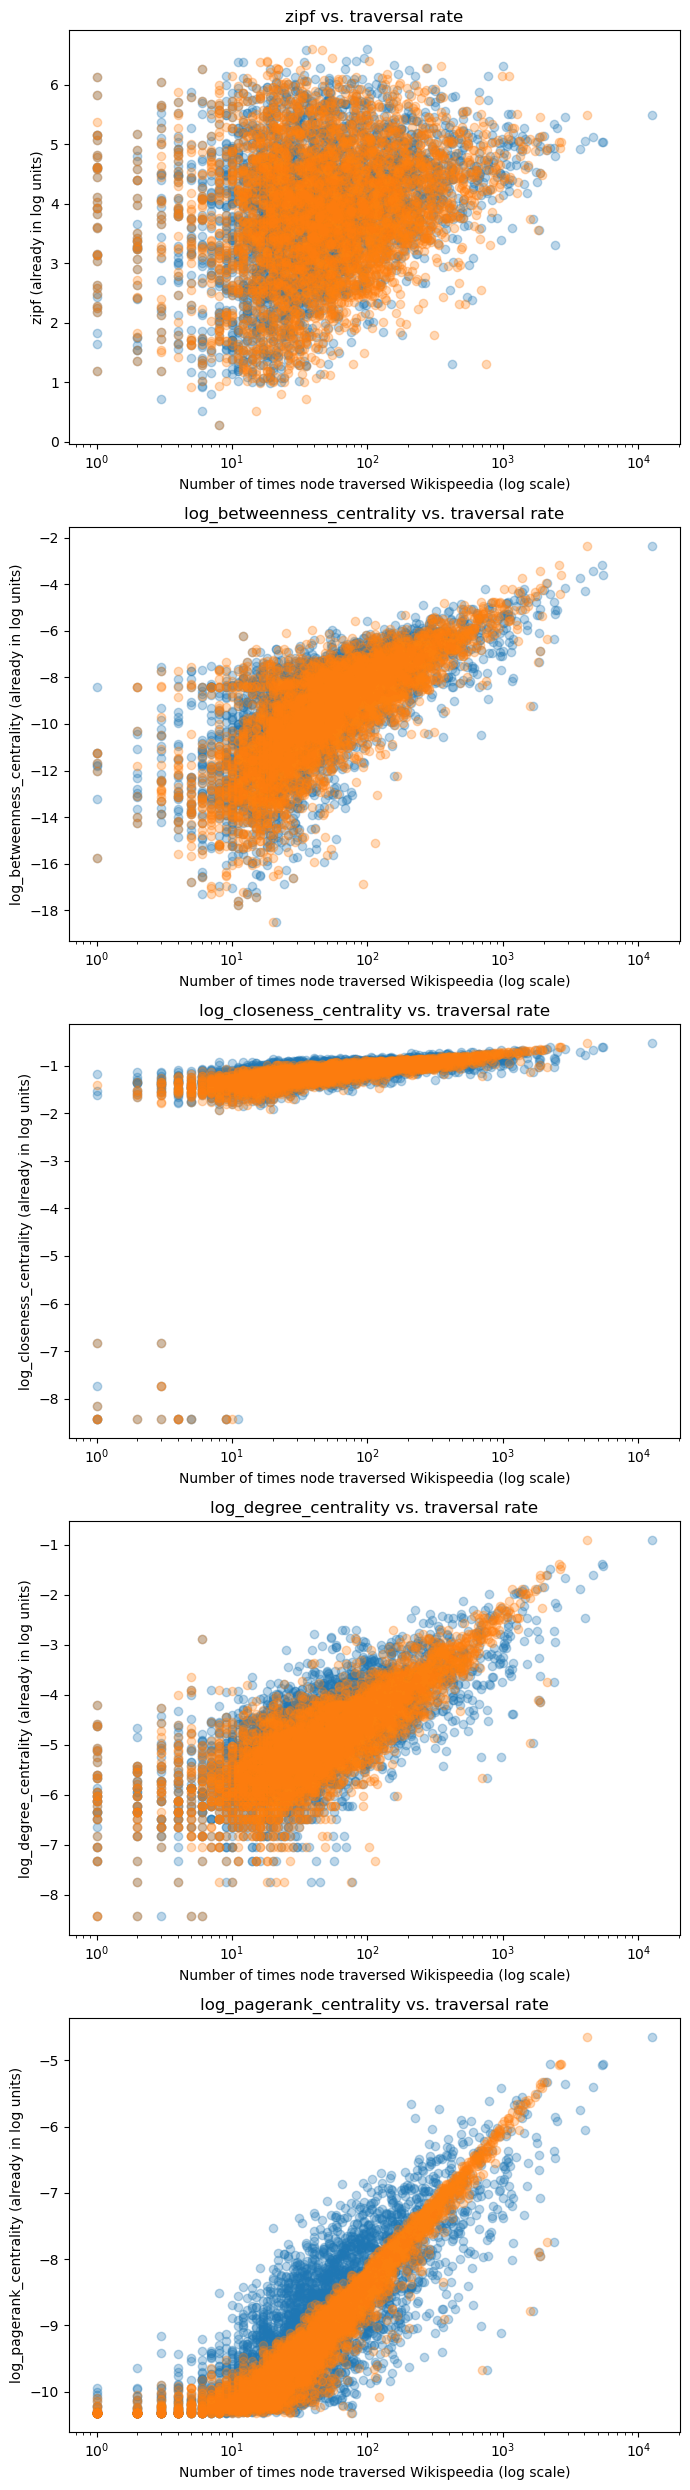

In [57]:
fig, axes = plt.subplots(5, 1, figsize=(7, 25))

ax = axes[0]
compare_centralities_with_node_traversals(
    word_frequency_centrality,
    node_counts,
    random_walker_node_counts,
    ax=ax,
    centrality_str="zipf",
)

ax = axes[1]
log_betweenness_centrality = {
    k: 0 if v == 0 else np.log(v) for k, v in betweenness_centrality.items()
}
compare_centralities_with_node_traversals(
    log_betweenness_centrality,
    node_counts,
    random_walker_node_counts,
    ax=ax,
    centrality_str="log_betweenness_centrality",
)

ax = axes[2]
log_closeness_centrality = {
    k: 0 if v == 0 else np.log(v) for k, v in closeness_centrality.items()
}
compare_centralities_with_node_traversals(
    log_closeness_centrality,
    node_counts,
    random_walker_node_counts,
    ax=ax,
    centrality_str="log_closeness_centrality",
)

ax = axes[3]
log_degree_centrality = {
    k: 0 if v == 0 else np.log(v) for k, v in degree_centrality.items()
}
compare_centralities_with_node_traversals(
    log_degree_centrality,
    node_counts,
    random_walker_node_counts,
    ax=ax,
    centrality_str="log_degree_centrality",
)

ax = axes[4]
log_pagerank_centrality = {
    k: 0 if v == 0 else np.log(v) for k, v in pagerank_centrality.items()
}
compare_centralities_with_node_traversals(
    log_pagerank_centrality,
    node_counts,
    random_walker_node_counts,
    ax=ax,
    centrality_str="log_pagerank_centrality",
)
plt.tight_layout()
plt.show()


## 3. Saturation of Flow Trees

### Path Flow Trees

In [6]:
# find most common paths
k = 50
path_counts = trajs_df.groupby(["StartEnd"]).size().sort_values(ascending=False)
most_common_paths = path_counts[:k].index.tolist()

print(
    f"Most common start node is {most_common_paths[0]} with {path_counts.iloc[0]} attempts."
)
print(
    f"{k}th most common start node is {most_common_paths[-1]} with {path_counts.iloc[k - 1]} attempts"
)

Most common start node is Brain_Telephone with 1849 attempts.
50th most common start node is Batman_Albert_Einstein with 22 attempts


In [55]:
path_saturation_dict = {}
k_saturation_levels = 10
for start_end in most_common_paths:
    this_df = trajs_df[(trajs_df["StartEnd"] == start_end)]

    trees = []
    n_trajss = []
    accs = []

    top_idx = min(100, len(this_df["traj"]))
    idxs = np.linspace(10, top_idx, k_saturation_levels, dtype=int)
    for n_trajs in idxs:
        sampled_trajs = this_df["traj"].to_numpy()[:n_trajs]

        # sampled_indices = np.random.choice(
        #     len(sampled_trajs), size=n_trajs, replace=False
        # )
        # sampled_trajs = [sampled_trajs[i] for i in sampled_indices]

        G = generate_flow_tree_from_trajs(sampled_trajs, END_NODE="1")
        new_G = nx.relabel.convert_node_labels_to_integers(
            G, first_label=0, ordering="default"
        )
        if (0, 0) in new_G.edges:
            new_G.remove_edge(0, 0)
        trees.append(new_G)
        n_trajss.append(n_trajs)
    # accs.append(this_df["finished"].mean())
    path_saturation_dict[(start_end)] = {"trees": trees, "n_trajs": n_trajss}

print(path_saturation_dict)

{'Brain_Telephone': {'trees': [<networkx.classes.graph.Graph object at 0x30fccb6d0>, <networkx.classes.graph.Graph object at 0x30ba38610>, <networkx.classes.graph.Graph object at 0x2f1039c50>, <networkx.classes.graph.Graph object at 0x2f0c91c50>, <networkx.classes.graph.Graph object at 0x2f0c5cb50>, <networkx.classes.graph.Graph object at 0x2f0cb8390>, <networkx.classes.graph.Graph object at 0x2f0cd6990>, <networkx.classes.graph.Graph object at 0x2f0ca1190>, <networkx.classes.graph.Graph object at 0x2f0c74490>, <networkx.classes.graph.Graph object at 0x31152bed0>], 'n_trajs': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]}, 'Theatre_Zebra': {'trees': [<networkx.classes.graph.Graph object at 0x2f0c810d0>, <networkx.classes.graph.Graph object at 0x2f0c83050>, <networkx.classes.graph.Graph object at 0x2f0cc9f10>, <networkx.classes.graph.Graph object at 0x2f0c48150>, <networkx.classes.graph.Graph object at 0x2f0c55190>, <networkx.classes.graph.Graph object at 0x2f0c00f50>, <networkx.classes.gra

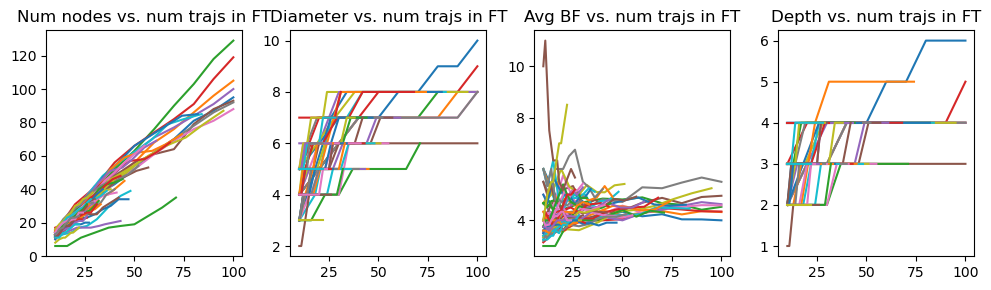

In [67]:
fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for path in path_saturation_dict:
    num_nodes = [G.number_of_nodes() for G in path_saturation_dict[path]["trees"]]
    axes[0].plot(path_saturation_dict[path]["n_trajs"], num_nodes)
axes[0].set_title("Num nodes vs. num trajs in FT")

for path in path_saturation_dict:
    diams = [nx.diameter(G) for G in path_saturation_dict[path]["trees"]]
    axes[1].plot(path_saturation_dict[path]["n_trajs"], diams)
axes[1].set_title("Diameter vs. num trajs in FT")


def compute_avg_bf(G, with_leaves=False):
    bfs = []
    for node in G.nodes():
        num_neighbors = len(list(G.neighbors(node)))
        if (with_leaves) or (num_neighbors > 1):
            bfs.append(num_neighbors)
    return np.mean(bfs)


for path in path_saturation_dict:
    bfs = [compute_avg_bf(G) for G in path_saturation_dict[path]["trees"]]
    axes[2].plot(path_saturation_dict[path]["n_trajs"], bfs)
axes[2].set_title("Avg BF vs. num trajs in FT")


# Tree Depth (Height)
def tree_depth(graph, root):
    depths = nx.single_source_shortest_path_length(graph, root)
    return max(depths.values())


for path in path_saturation_dict:
    depths = [tree_depth(G, 0) for G in path_saturation_dict[path]["trees"]]
    axes[3].plot(path_saturation_dict[path]["n_trajs"], depths)
axes[3].set_title("Depth vs. num trajs in FT")

plt.tight_layout()
plt.show()

### Node Flow Trees

In [42]:
node_counts = {}
for trajectory in trajs_df.traj:
    for node in trajectory:
        node_counts[node] = node_counts.get(node, 0) + 1

# find most common nodes
k = 100
most_common_nodes = sorted(
    [x for x in node_counts], key=lambda x: node_counts[x], reverse=True
)[:k]

print(
    f"Most common node is {most_common_nodes[0]} with {node_counts[most_common_nodes[0]]} attempts."
)
print(
    f"{k}th most common node is {most_common_nodes[-1]} with {node_counts[most_common_nodes[-1]]} attempts"
)

Most common node is United_States with 12660 attempts.
100th most common node is Electricity with 670 attempts


In [64]:
traj_dict = {x: [] for x in most_common_nodes}
for traj in trajs_df.traj:
    for i in range(len(traj) - 7):  # want min path length 5?
        if traj[i] in most_common_nodes:
            traj_dict[traj[i]].append(traj[i : i + 6])


print(np.min([len(traj_dict[x]) for x in traj_dict]))

node_saturation_dict = {}
k_saturation_levels = 10
for node in most_common_nodes:
    trees = []
    n_trajss = []

    top_idx = min(200, len(traj_dict[node]))
    idxs = np.linspace(10, top_idx, k_saturation_levels, dtype=int)
    for n_trajs in idxs:
        sampled_trajs = traj_dict[node][:n_trajs]

        # sampled_indices = np.random.choice(
        #     len(sampled_trajs), size=n_trajs, replace=False
        # )
        # sampled_trajs = [sampled_trajs[i] for i in sampled_indices]

        G = generate_flow_tree_from_trajs(sampled_trajs, END_NODE="1")
        new_G = nx.relabel.convert_node_labels_to_integers(
            G, first_label=0, ordering="default"
        )
        if (0, 0) in new_G.edges:
            new_G.remove_edge(0, 0)
        trees.append(new_G)
        n_trajss.append(n_trajs)
    node_saturation_dict[(node)] = {"trees": trees, "n_trajs": n_trajss}

print(node_saturation_dict)

19
{'United_States': {'trees': [<networkx.classes.graph.Graph object at 0x30dfab310>, <networkx.classes.graph.Graph object at 0x3165525d0>, <networkx.classes.graph.Graph object at 0x3068a3310>, <networkx.classes.graph.Graph object at 0x307fc5d90>, <networkx.classes.graph.Graph object at 0x2f1053a10>, <networkx.classes.graph.Graph object at 0x2e137c490>, <networkx.classes.graph.Graph object at 0x306836510>, <networkx.classes.graph.Graph object at 0x2dc019290>, <networkx.classes.graph.Graph object at 0x2e0b6a010>, <networkx.classes.graph.Graph object at 0x2e01d5ad0>], 'n_trajs': [10, 31, 52, 73, 94, 115, 136, 157, 178, 200]}, 'Europe': {'trees': [<networkx.classes.graph.Graph object at 0x3114e4050>, <networkx.classes.graph.Graph object at 0x2dc02d850>, <networkx.classes.graph.Graph object at 0x2e12a7fd0>, <networkx.classes.graph.Graph object at 0x2dc02bf50>, <networkx.classes.graph.Graph object at 0x310367110>, <networkx.classes.graph.Graph object at 0x307a3ded0>, <networkx.classes.graph

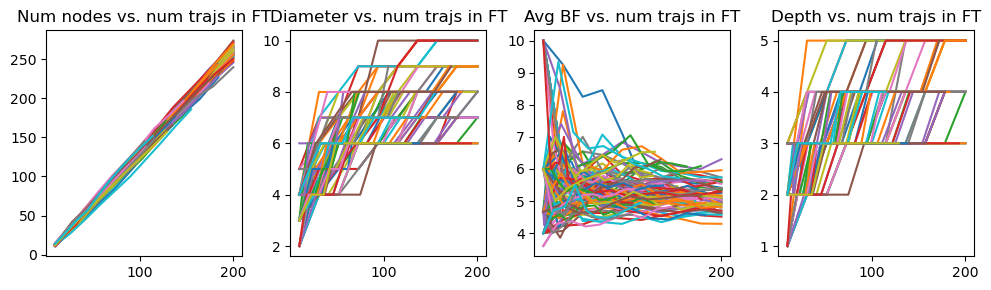

In [68]:
fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for node in node_saturation_dict:
    num_nodes = [G.number_of_nodes() for G in node_saturation_dict[node]["trees"]]
    axes[0].plot(node_saturation_dict[node]["n_trajs"], num_nodes)
axes[0].set_title("Num nodes vs. num trajs in FT")

for node in node_saturation_dict:
    diams = [nx.diameter(G) for G in node_saturation_dict[node]["trees"]]
    axes[1].plot(node_saturation_dict[node]["n_trajs"], diams)
axes[1].set_title("Diameter vs. num trajs in FT")


for node in node_saturation_dict:
    bfs = [compute_avg_bf(G) for G in node_saturation_dict[node]["trees"]]
    axes[2].plot(node_saturation_dict[node]["n_trajs"], bfs)
axes[2].set_title("Avg BF vs. num trajs in FT")

for node in node_saturation_dict:
    depths = [tree_depth(G, 0) for G in node_saturation_dict[node]["trees"]]
    axes[3].plot(node_saturation_dict[node]["n_trajs"], depths)
axes[3].set_title("Depth vs. num trajs in FT")


plt.tight_layout()
plt.show()

### Reverse node

In [60]:
rev_traj_dict = {x: [] for x in most_common_nodes}
for traj in trajs_df.traj:
    for i in range(5, len(traj)):  # want min path length 7?
        if traj[i] in most_common_nodes:
            rev_traj = [x for x in reversed(traj[i - 5 : i])]
            rev_traj_dict[traj[i]].append(rev_traj)


print(np.min([len(rev_traj_dict[x]) for x in rev_traj_dict]))

reverse_node_saturation_dict = {}
k_saturation_levels = 10
for node in most_common_nodes:
    trees = []
    n_trajss = []

    top_idx = min(200, len(rev_traj_dict[node]))
    idxs = np.linspace(10, top_idx, k_saturation_levels, dtype=int)
    for n_trajs in idxs:
        sampled_trajs = rev_traj_dict[node][:n_trajs]

        # sampled_indices = np.random.choice(
        #     len(sampled_trajs), size=n_trajs, replace=False
        # )
        # sampled_trajs = [sampled_trajs[i] for i in sampled_indices]

        G = generate_flow_tree_from_trajs(sampled_trajs, END_NODE="1")
        new_G = nx.relabel.convert_node_labels_to_integers(
            G, first_label=0, ordering="default"
        )
        if (0, 0) in new_G.edges:
            new_G.remove_edge(0, 0)
        trees.append(new_G)
        n_trajss.append(n_trajs)
    reverse_node_saturation_dict[(node)] = {"trees": trees, "n_trajs": n_trajss}

print(reverse_node_saturation_dict)

24
{'United_States': {'trees': [<networkx.classes.graph.Graph object at 0x2e392b310>, <networkx.classes.graph.Graph object at 0x2e8016750>, <networkx.classes.graph.Graph object at 0x2f0b70950>, <networkx.classes.graph.Graph object at 0x2f1c69a10>, <networkx.classes.graph.Graph object at 0x306548ed0>, <networkx.classes.graph.Graph object at 0x2f1c6b690>, <networkx.classes.graph.Graph object at 0x2e804ad90>, <networkx.classes.graph.Graph object at 0x2e804a590>, <networkx.classes.graph.Graph object at 0x2f0be9290>, <networkx.classes.graph.Graph object at 0x2f1c92a50>], 'n_trajs': [10, 31, 52, 73, 94, 115, 136, 157, 178, 200]}, 'Europe': {'trees': [<networkx.classes.graph.Graph object at 0x2f0bce290>, <networkx.classes.graph.Graph object at 0x30a2aaf10>, <networkx.classes.graph.Graph object at 0x2e7bc6790>, <networkx.classes.graph.Graph object at 0x2f0bce450>, <networkx.classes.graph.Graph object at 0x2e7bbb810>, <networkx.classes.graph.Graph object at 0x2e80aad10>, <networkx.classes.graph

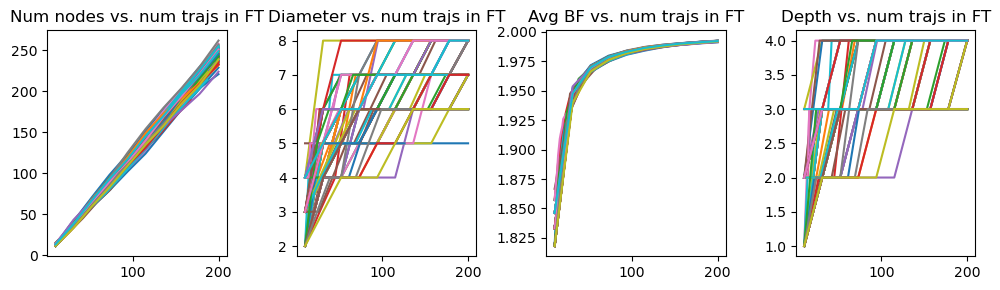

In [61]:
fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for node in reverse_node_saturation_dict:
    num_nodes = [
        G.number_of_nodes() for G in reverse_node_saturation_dict[node]["trees"]
    ]
    axes[0].plot(reverse_node_saturation_dict[node]["n_trajs"], num_nodes)
axes[0].set_title("Num nodes vs. num trajs in FT")

for node in reverse_node_saturation_dict:
    diams = [nx.diameter(G) for G in reverse_node_saturation_dict[node]["trees"]]
    axes[1].plot(reverse_node_saturation_dict[node]["n_trajs"], diams)
axes[1].set_title("Diameter vs. num trajs in FT")

for node in reverse_node_saturation_dict:
    bfs = [compute_avg_bf(G) for G in reverse_node_saturation_dict[node]["trees"]]
    axes[2].plot(reverse_node_saturation_dict[node]["n_trajs"], bfs)
axes[2].set_title("Avg BF vs. num trajs in FT")

for node in reverse_node_saturation_dict:
    depths = [tree_depth(G, 0) for G in reverse_node_saturation_dict[node]["trees"]]
    axes[3].plot(reverse_node_saturation_dict[node]["n_trajs"], depths)
axes[3].set_title("Depth vs. num trajs in FT")


plt.tight_layout()
plt.show()

## 2. Set up how to run hypothesis test

1. Compute Flow Trees
2. Compute features on Flow Trees
3. Run appropriate statistical test


In [7]:
from scipy.spatial.distance import pdist
from scipy import stats


def vector_statistic(x, y, axis):
    mean_x = np.mean(x, axis=axis)
    mean_y = np.mean(y, axis=axis)

    # Calculate Euclidean distance
    dist = mean_x - mean_y
    # print(f"Distance between means: {dist}")  # Debug print

    return dist


def run_ttest(group1_reps, group2_reps, statistic=vector_statistic):
    # Perform a t-test on groups
    t_stat, p_value = stats.ttest_ind(group1_reps, group2_reps)
    print(
        f"Group 1 mean: {np.mean(group1_reps):.2f} (var={np.var(group1_reps):.2f}; n={len(group1_reps)})"
    )
    print(
        f"Group 2 mean: {np.mean(group2_reps):.2f} (var={np.var(group2_reps):.2f}; n={len(group2_reps)})"
    )
    print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")

    # mean1, var1, n1 = np.mean(group1_reps), np.var(group1_reps), len(group1_reps)
    # mean2, var2, n2 = np.mean(group2_reps), np.var(group2_reps), len(group2_reps)
    # t = (mean1 - mean2) / np.sqrt((var1/n1 + var2/n2))
    # print("Number samples:", n1, n2)
    # print("T homemade:", t)

    return t_stat, p_value


def run_permutation_test(group1_reps, group2_reps, statistic=vector_statistic):
    res = stats.permutation_test(
        (group1_reps, group2_reps),
        statistic,
        vectorized=True,
        n_resamples=9999,  # np.inf,
        alternative="two-sided",
    )
    print(f"Permutation test result: {res.statistic:.4} (p={res.pvalue:.4})")

    if len(group1_reps.shape) == 1:
        group1_reps = group1_reps.reshape(-1, 1)
    if len(group2_reps.shape) == 1:
        group2_reps = group2_reps.reshape(-1, 1)

    all_group_dist = pdist(np.concatenate([group1_reps, group2_reps]))

    within_group1_dist = pdist(group1_reps)
    within_group2_dist = pdist(group2_reps)
    within_group_dist = np.concatenate([within_group1_dist, within_group2_dist])

    print(
        f"Mean within group 1 dist: {np.mean(within_group1_dist):.2} (var={np.var(within_group1_dist):.2})"
    )
    print(
        f"Mean within group 2 dist: {np.mean(within_group2_dist):.2} (var={np.var(within_group2_dist):.2})"
    )
    print(
        f"Mean between all group dist: {np.mean(all_group_dist):.2} (var={np.var(all_group_dist):.2})"
    )

    res2 = stats.permutation_test(
        (within_group1_dist, all_group_dist),
        statistic,
        vectorized=True,
        n_resamples=9999,  # np.inf,
        alternative="less",
    )  # within group dist should be less than between
    print(f"Within group 1 dist vs among all: {res2.statistic:.4} (p={res2.pvalue:.4})")
    t_stat, p_value = stats.ttest_ind(within_group1_dist, all_group_dist)
    print(f"\tT-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")

    res2 = stats.permutation_test(
        (within_group2_dist, all_group_dist),
        statistic,
        vectorized=True,
        n_resamples=9999,  # np.inf,
        alternative="less",
    )  # within group dist should be less than between
    print(f"Within group 2 dist vs among all: {res2.statistic:.4} (p={res2.pvalue:.4})")
    t_stat, p_value = stats.ttest_ind(within_group2_dist, all_group_dist)
    print(f"\tT-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")

    res2 = stats.permutation_test(
        (within_group1_dist, within_group2_dist),
        statistic,
        vectorized=True,
        n_resamples=9999,  # np.inf,
        alternative="less",
    )  # within group dist should be less than between
    print(
        f"Within group 1 dist vs within group 2: {res2.statistic:.4} (p={res2.pvalue:.4})"
    )
    t_stat, p_value = stats.ttest_ind(within_group1_dist, within_group2_dist)
    print(f"\tT-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")


def euc_dist_between_means(x, y):
    return np.linalg.norm(np.mean(x, axis=0) - np.mean(y, axis=0))


def run_homemade_permutation_test(
    group1, group2, statistic=euc_dist_between_means, n_permutations=9999
):
    observed = statistic(group1, group2)

    data = np.concatenate([group1, group2])
    rng = np.random.default_rng()

    n_samples = len(data)

    n_group1 = len(group1)

    perm_generator = (rng.permutation(n_samples) for i in range(n_permutations))

    def _batch_generator(iterable, batch):
        """A generator that yields batches of elements from an iterable"""
        iterator = iter(iterable)
        if batch <= 0:
            raise ValueError("`batch` must be positive.")
        z = [item for i, item in zip(range(batch), iterator)]
        while z:  # we don't want StopIteration without yielding an empty list
            yield z
            z = [item for i, item in zip(range(batch), iterator)]

    null_distribution = []
    for indices in _batch_generator(perm_generator, batch=n_permutations):
        indices = np.array(indices)  # shape: [num permutations, num samples]

        for permutation in indices:
            data_batch = data[permutation, ...]

            permuted_group1 = data_batch[:n_group1, ...]
            permuted_group2 = data_batch[n_group1:, ...]

            permuted_statistic = statistic(permuted_group1, permuted_group2)
            null_distribution.append(permuted_statistic)

    null_distribution = np.array(null_distribution)

    adjustment = 1
    n_resamples = n_permutations

    def less(null_distribution, observed):
        cmps = null_distribution <= observed  # + gamma
        pvalues = (cmps.sum(axis=0) + adjustment) / (n_resamples + adjustment)
        return pvalues

    def greater(null_distribution, observed):
        cmps = null_distribution >= observed  # - gamma
        pvalues = (cmps.sum(axis=0) + adjustment) / (n_resamples + adjustment)
        return pvalues

    def two_sided(null_distribution, observed):
        pvalues_less = less(null_distribution, observed)
        pvalues_greater = greater(null_distribution, observed)
        pvalues = np.minimum(pvalues_less, pvalues_greater) * 2
        return pvalues

    pvalue = two_sided(null_distribution, observed)
    # print(f"Permutation test: {observed:.4f} (p={pvalue:.4f})")

    return observed, pvalue

## 3. Run hypothesis tests

Steps:
1. Make groups
2. Run tests
3. Add results to df

Hypotheses tested:
semantics
generality
centrality
(harder) before/after zoom in (maybe look at switch points)

In [8]:
# Create a DataFrame to store hypothesis test results
def get_new_results_df():
    return pd.DataFrame(
        columns=[
            "hypothesis",
            "test_type",
            "group1_name",
            "group2_name",
            "group1_mean",
            "group2_mean",
            "group1_var",
            "group2_var",
            "group1_n",
            "group2_n",
            "statistic",
            "p_value",
            "significant",
            "metric",
            "notes",
        ]
    )


all_results_df = get_new_results_df()

In [9]:
def get_heaviest_path(tree, root):
    # Get all leaves (nodes with degree 1, excluding the root)
    leaves = [node for node in tree.nodes() if tree.degree(node) == 1 and node != root]
    # leaves = [node for node in tree.nodes() if tree.nodes[node].get("color", "white") in ["yellow", "green"]]

    def dfs(node, current_path, current_weight):
        nonlocal max_weight, heaviest_path

        # If we're at a leaf (degree 1 and not root)
        if node in leaves:
            if current_weight > max_weight:
                max_weight = current_weight
                heaviest_path = current_path.copy()
            return

        # Explore all children
        for neighbor in tree.neighbors(node):
            if neighbor not in current_path:  # Avoid cycles
                edge_weight = tree[node][neighbor]["weight"]
                current_path.append(neighbor)
                dfs(neighbor, current_path, current_weight + edge_weight)
                current_path.pop()

    max_weight = float("-inf")
    heaviest_path = None
    dfs(root, [root], 0)

    return (
        heaviest_path,
        max_weight,
        [
            tree[heaviest_path[i]][heaviest_path[i + 1]]["weight"]
            for i in range(len(heaviest_path) - 1)
        ],
    )


def extract_tree_features(graph, root):
    # Number of Nodes
    num_nodes = graph.number_of_nodes()

    # Tree Depth (Height)
    def tree_depth(graph, root):
        depths = nx.single_source_shortest_path_length(graph, root)
        return max(depths.values())

    depth = tree_depth(graph, root)

    # Diameter
    diameter = nx.diameter(graph)

    backbone_path, max_weight, weights = get_heaviest_path(graph, root)
    backbone_thickness = np.mean(weights) / max_weight

    # Number of Leaves
    num_leaves = sum(1 for node in graph.nodes() if graph.degree(node) == 1)

    # Branching Factor
    branching_factors = [len(list(graph.neighbors(node))) for node in graph.nodes()]
    avg_branching_factor = np.mean(branching_factors)

    # Put all features in a list
    features = [
        num_nodes,
        num_leaves,
        depth,
        avg_branching_factor,
        backbone_thickness,
        diameter,
    ]

    return features


def compare_flow_tree_groups(
    results_df,
    group1_trees,
    group2_trees,
    normalise=False,
    include_embeddings=True,
    hypothesis_test_types=["permutation"],
    group1_name="Group 1",
    group2_name="Group 2",
    hypothesis="",
):
    """Compare two groups of flow trees on various structural metrics.

    Args:
        results_df
        group1_trees: List of networkx graphs for first group
        group2_trees: List of networkx graphs for second group
        group1_name: Name of first group for results
        group2_name: Name of second group for results
        hypothesis: Hypothesis being tested

    Returns:
        DataFrame containing test results
    """
    feature_names = [
        "num_nodes",
        "num_leaves",
        "depth",
        "avg_branching_factor",
        "backbone_thickness",
        "diameter",
    ]

    # Add embeddings to features arrays
    group1_features = np.array([extract_tree_features(G, 0) for G in group1_trees])
    group2_features = np.array([extract_tree_features(G, 0) for G in group2_trees])

    # Test each feature
    for i, feature_name in enumerate(feature_names):
        group1_feature = group1_features[:, i]
        group2_feature = group2_features[:, i]

        if normalise:
            # Normalize features to 0-1 range
            all_features = np.concatenate([group1_feature, group2_feature])
            feature_min = np.min(all_features)
            feature_max = np.max(all_features)

            # Avoid division by zero if min==max
            if feature_max > feature_min:
                group1_feature = (group1_feature - feature_min) / (
                    feature_max - feature_min
                )
                group2_feature = (group2_feature - feature_min) / (
                    feature_max - feature_min
                )

        if "t-test" in hypothesis_test_types:
            # T-test
            t_stat, p_val = stats.ttest_ind(group1_feature, group2_feature)
            results_df.loc[len(results_df)] = {
                "hypothesis": hypothesis,
                "test_type": "t-test",
                "group1_name": group1_name,
                "group2_name": group2_name,
                "group1_mean": np.mean(group1_feature),
                "group2_mean": np.mean(group2_feature),
                "group1_var": np.var(group1_feature),
                "group2_var": np.var(group2_feature),
                "group1_n": len(group1_feature),
                "group2_n": len(group2_feature),
                "statistic": t_stat,
                "p_value": p_val,
                "significant": p_val < 0.05,
                "metric": feature_name,
                "notes": f"Comparing flow tree {feature_name} between {group1_name} and {group2_name}",
            }

        if "permutation" in hypothesis_test_types:
            # Permutation test
            perm_stat, perm_p = run_homemade_permutation_test(
                group1_feature, group2_feature
            )
            results_df.loc[len(results_df)] = {
                "hypothesis": hypothesis,
                "test_type": "permutation",
                "group1_name": group1_name,
                "group2_name": group2_name,
                "group1_mean": np.mean(group1_feature),
                "group2_mean": np.mean(group2_feature),
                "group1_var": np.var(group1_feature),
                "group2_var": np.var(group2_feature),
                "group1_n": len(group1_feature),
                "group2_n": len(group2_feature),
                "statistic": perm_stat,
                "p_value": perm_p,
                "significant": perm_p < 0.05,
                "metric": feature_name,
                "notes": f"Permutation test on flow tree {feature_name} between {group1_name} and {group2_name}",
            }

    if include_embeddings:
        # Initialize Graph2Vec embedder
        test_flow_tree_embedder = kc.Graph2Vec(dimensions=64)
        test_flow_tree_embedder.fit(group1_trees + group2_trees)

        # Get embeddings
        group1_embeddings = test_flow_tree_embedder.infer(group1_trees)
        group2_embeddings = test_flow_tree_embedder.infer(group2_trees)

        # Get PCA-1 and PCA-2 of embeddings?

        # Permutation test
        perm_stat, perm_p = run_homemade_permutation_test(
            group1_embeddings, group2_embeddings
        )
        results_df.loc[len(results_df)] = {
            "hypothesis": hypothesis,
            "test_type": "permutation",
            "group1_name": group1_name,
            "group2_name": group2_name,
            "group1_mean": np.mean(group1_embeddings),
            "group2_mean": np.mean(group2_embeddings),
            "group1_var": np.var(group1_embeddings),
            "group2_var": np.var(group2_embeddings),
            "group1_n": len(group1_embeddings),
            "group2_n": len(group2_embeddings),
            "statistic": perm_stat,
            "p_value": perm_p,
            "significant": perm_p < 0.05,
            "metric": "graph2vec embeddings",
            "notes": f"Permutation test on flow tree {feature_name} between {group1_name} and {group2_name}",
        }

        group1_features = np.append(
            group1_features, np.mean(group1_embeddings, axis=1).reshape(-1, 1), axis=1
        )
        group2_features = np.append(
            group2_features, np.mean(group2_embeddings, axis=1).reshape(-1, 1), axis=1
        )

    return results_df, group1_features, group2_features


In [11]:
# def get_heaviest_path(tree, root):
#     # Get all leaves (nodes with degree 1, excluding the root)
#     leaves = [node for node in tree.nodes() if tree.degree(node) == 1 and node != root]
#     # leaves = [node for node in tree.nodes() if tree.nodes[node].get("color", "white") in ["yellow", "green"]]

#     def dfs(node, current_path, current_weight):
#         nonlocal max_weight, heaviest_path

#         # If we're at a leaf (degree 1 and not root)
#         if node in leaves:
#             if current_weight > max_weight:
#                 max_weight = current_weight
#                 heaviest_path = current_path.copy()
#             return

#         # Explore all children
#         for neighbor in tree.neighbors(node):
#             if neighbor not in current_path:  # Avoid cycles
#                 edge_weight = tree[node][neighbor]['weight']
#                 current_path.append(neighbor)
#                 dfs(neighbor, current_path, current_weight + edge_weight)
#                 current_path.pop()

#     max_weight = float('-inf')
#     heaviest_path = None
#     dfs(root, [root], 0)

#     return heaviest_path, max_weight, [tree[heaviest_path[i]][heaviest_path[i+1]]['weight'] for i in range(len(heaviest_path)-1)]

# def extract_tree_features(graph, root):
#     # Number of Nodes
#     num_nodes = graph.number_of_nodes()

#     # Tree Depth (Height)
#     def tree_depth(graph, root):
#         depths = nx.single_source_shortest_path_length(graph, root)
#         return max(depths.values())

#     depth = tree_depth(graph, root)

#     # Diameter
#     diameter = nx.diameter(graph)

#     backbone_path, max_weight, weights = get_heaviest_path(graph, root)
#     backbone_thickness = np.mean(weights) / max_weight

#     # Number of Leaves
#     num_leaves = sum(1 for node in graph.nodes() if graph.degree(node) == 1)

#     # Branching Factor
#     branching_factors = [len(list(graph.neighbors(node))) for node in graph.nodes()]
#     avg_branching_factor = np.mean(branching_factors)

#     # Put all features in a list
#     features = [
#         num_nodes,
#         num_leaves,
#         depth,
#         avg_branching_factor,
#         backbone_thickness,
#         diameter
#     ]

#     return features

# def compare_flow_tree_groups(results_df, group1_trees, group2_trees, normalise=False, include_embeddings=True, hypothesis_test_types=["permutation"], group1_name="Group 1", group2_name="Group 2", hypothesis=""):
#     """Compare two groups of flow trees on various structural metrics.

#     Args:
#         results_df
#         group1_trees: List of networkx graphs for first group
#         group2_trees: List of networkx graphs for second group
#         group1_name: Name of first group for results
#         group2_name: Name of second group for results
#         hypothesis: Hypothesis being tested

#     Returns:
#         DataFrame containing test results
#     """
#     feature_names = ['num_nodes', 'num_leaves', 'depth',  'avg_branching_factor', 'backbone_thickness','diameter',]

#     # Add embeddings to features arrays
#     group1_features = np.array([extract_tree_features(G, 0) for G in group1_trees])
#     group2_features = np.array([extract_tree_features(G, 0) for G in group2_trees])

#     # Test each feature
#     for i, feature_name in enumerate(feature_names):
#         group1_feature = group1_features[:, i]
#         group2_feature = group2_features[:, i]

#         if normalise:
#             # Normalize features to 0-1 range
#             all_features = np.concatenate([group1_feature, group2_feature])
#             feature_min = np.min(all_features)
#             feature_max = np.max(all_features)

#             # Avoid division by zero if min==max
#             if feature_max > feature_min:
#                 group1_feature = (group1_feature - feature_min) / (feature_max - feature_min)
#                 group2_feature = (group2_feature - feature_min) / (feature_max - feature_min)

#         if "t-test" in hypothesis_test_types:
#             # T-test
#             t_stat, p_val = stats.ttest_ind(group1_feature, group2_feature)
#             results_df.loc[len(results_df)] = {
#                 'hypothesis': hypothesis,
#                 'test_type': 't-test',
#                 'group1_name': group1_name,
#                 'group2_name': group2_name,
#                 'group1_mean': np.mean(group1_feature),
#                 'group2_mean': np.mean(group2_feature),
#                 'group1_var': np.var(group1_feature),
#                 'group2_var': np.var(group2_feature),
#                 'group1_n': len(group1_feature),
#                 'group2_n': len(group2_feature),
#                 'statistic': t_stat,
#                 'p_value': p_val,
#                 'significant': p_val < 0.05,
#                 'metric': feature_name,
#                 'notes': f'Comparing flow tree {feature_name} between {group1_name} and {group2_name}'
#             }

#         if "permutation" in hypothesis_test_types:
#             # Permutation test
#             perm_stat, perm_p = run_homemade_permutation_test(group1_feature, group2_feature)
#             results_df.loc[len(results_df)] = {
#                 'hypothesis': hypothesis,
#                 'test_type': 'permutation',
#                 'group1_name': group1_name,
#                 'group2_name': group2_name,
#                 'group1_mean': np.mean(group1_feature),
#                 'group2_mean': np.mean(group2_feature),
#                 'group1_var': np.var(group1_feature),
#                 'group2_var': np.var(group2_feature),
#                 'group1_n': len(group1_feature),
#                 'group2_n': len(group2_feature),
#                 'statistic': perm_stat,
#                 'p_value': perm_p,
#                 'significant': perm_p < 0.05,
#                 'metric': feature_name,
#                 'notes': f'Permutation test on flow tree {feature_name} between {group1_name} and {group2_name}'
#             }

#     if include_embeddings:
#         # Initialize Graph2Vec embedder
#         test_flow_tree_embedder = kc.Graph2Vec(dimensions=64)
#         test_flow_tree_embedder.fit(group1_trees + group2_trees)

#         # Get embeddings
#         group1_embeddings = test_flow_tree_embedder.infer(group1_trees)
#         group2_embeddings = test_flow_tree_embedder.infer(group2_trees)

#         # Get PCA-1 and PCA-2 of embeddings?

#         # Permutation test
#         perm_stat, perm_p = run_homemade_permutation_test(group1_embeddings, group2_embeddings)
#         results_df.loc[len(results_df)] = {
#             'hypothesis': hypothesis,
#             'test_type': 'permutation',
#             'group1_name': group1_name,
#             'group2_name': group2_name,
#             'group1_mean': np.mean(group1_embeddings),
#             'group2_mean': np.mean(group2_embeddings),
#             'group1_var': np.var(group1_embeddings),
#             'group2_var': np.var(group2_embeddings),
#             'group1_n': len(group1_embeddings),
#             'group2_n': len(group2_embeddings),
#             'statistic': perm_stat,
#             'p_value': perm_p,
#             'significant': perm_p < 0.05,
#             'metric': "graph2vec embeddings",
#             'notes': f'Permutation test on flow tree {feature_name} between {group1_name} and {group2_name}'
#         }

#         group1_features = np.append(group1_features, np.mean(group1_embeddings, axis=1).reshape(-1, 1), axis=1)
#         group2_features = np.append(group2_features, np.mean(group2_embeddings, axis=1).reshape(-1, 1), axis=1)

#     return results_df, group1_features, group2_features


## Path Flow Trees

In [15]:
# find most common paths
k = 50
path_counts = trajs_df.groupby(["StartEnd"]).size().sort_values(ascending=False)
most_common_paths = path_counts[:k].index.tolist()

print(
    f"Most common start node is {most_common_paths[0]} with {path_counts.iloc[0]} attempts."
)
print(
    f"{k}th most common start node is {most_common_paths[-1]} with {path_counts.iloc[k - 1]} attempts"
)

Most common start node is Brain_Telephone with 1849 attempts.
50th most common start node is Batman_Albert_Einstein with 22 attempts


In [16]:
trees_by_path = {}
fewest_attempts = 20
k_fold = 5
accs = []
for start_end in most_common_paths:
    this_df = trajs_df[(trajs_df["StartEnd"] == start_end)]
    trees = []
    for _ in range(k_fold):
        sampled_trajs = this_df["traj"].to_numpy()
        if len(sampled_trajs) > fewest_attempts:
            sampled_indices = np.random.choice(
                len(sampled_trajs), size=fewest_attempts, replace=False
            )
            sampled_trajs = [sampled_trajs[i] for i in sampled_indices]

        G = generate_flow_tree_from_trajs(sampled_trajs, END_NODE="1")
        new_G = nx.relabel.convert_node_labels_to_integers(
            G, first_label=0, ordering="default"
        )
        if (0, 0) in new_G.edges:
            new_G.remove_edge(0, 0)
        trees.append(new_G)
    accs.append(this_df["finished"].mean())
    trees_by_path[(start_end)] = trees

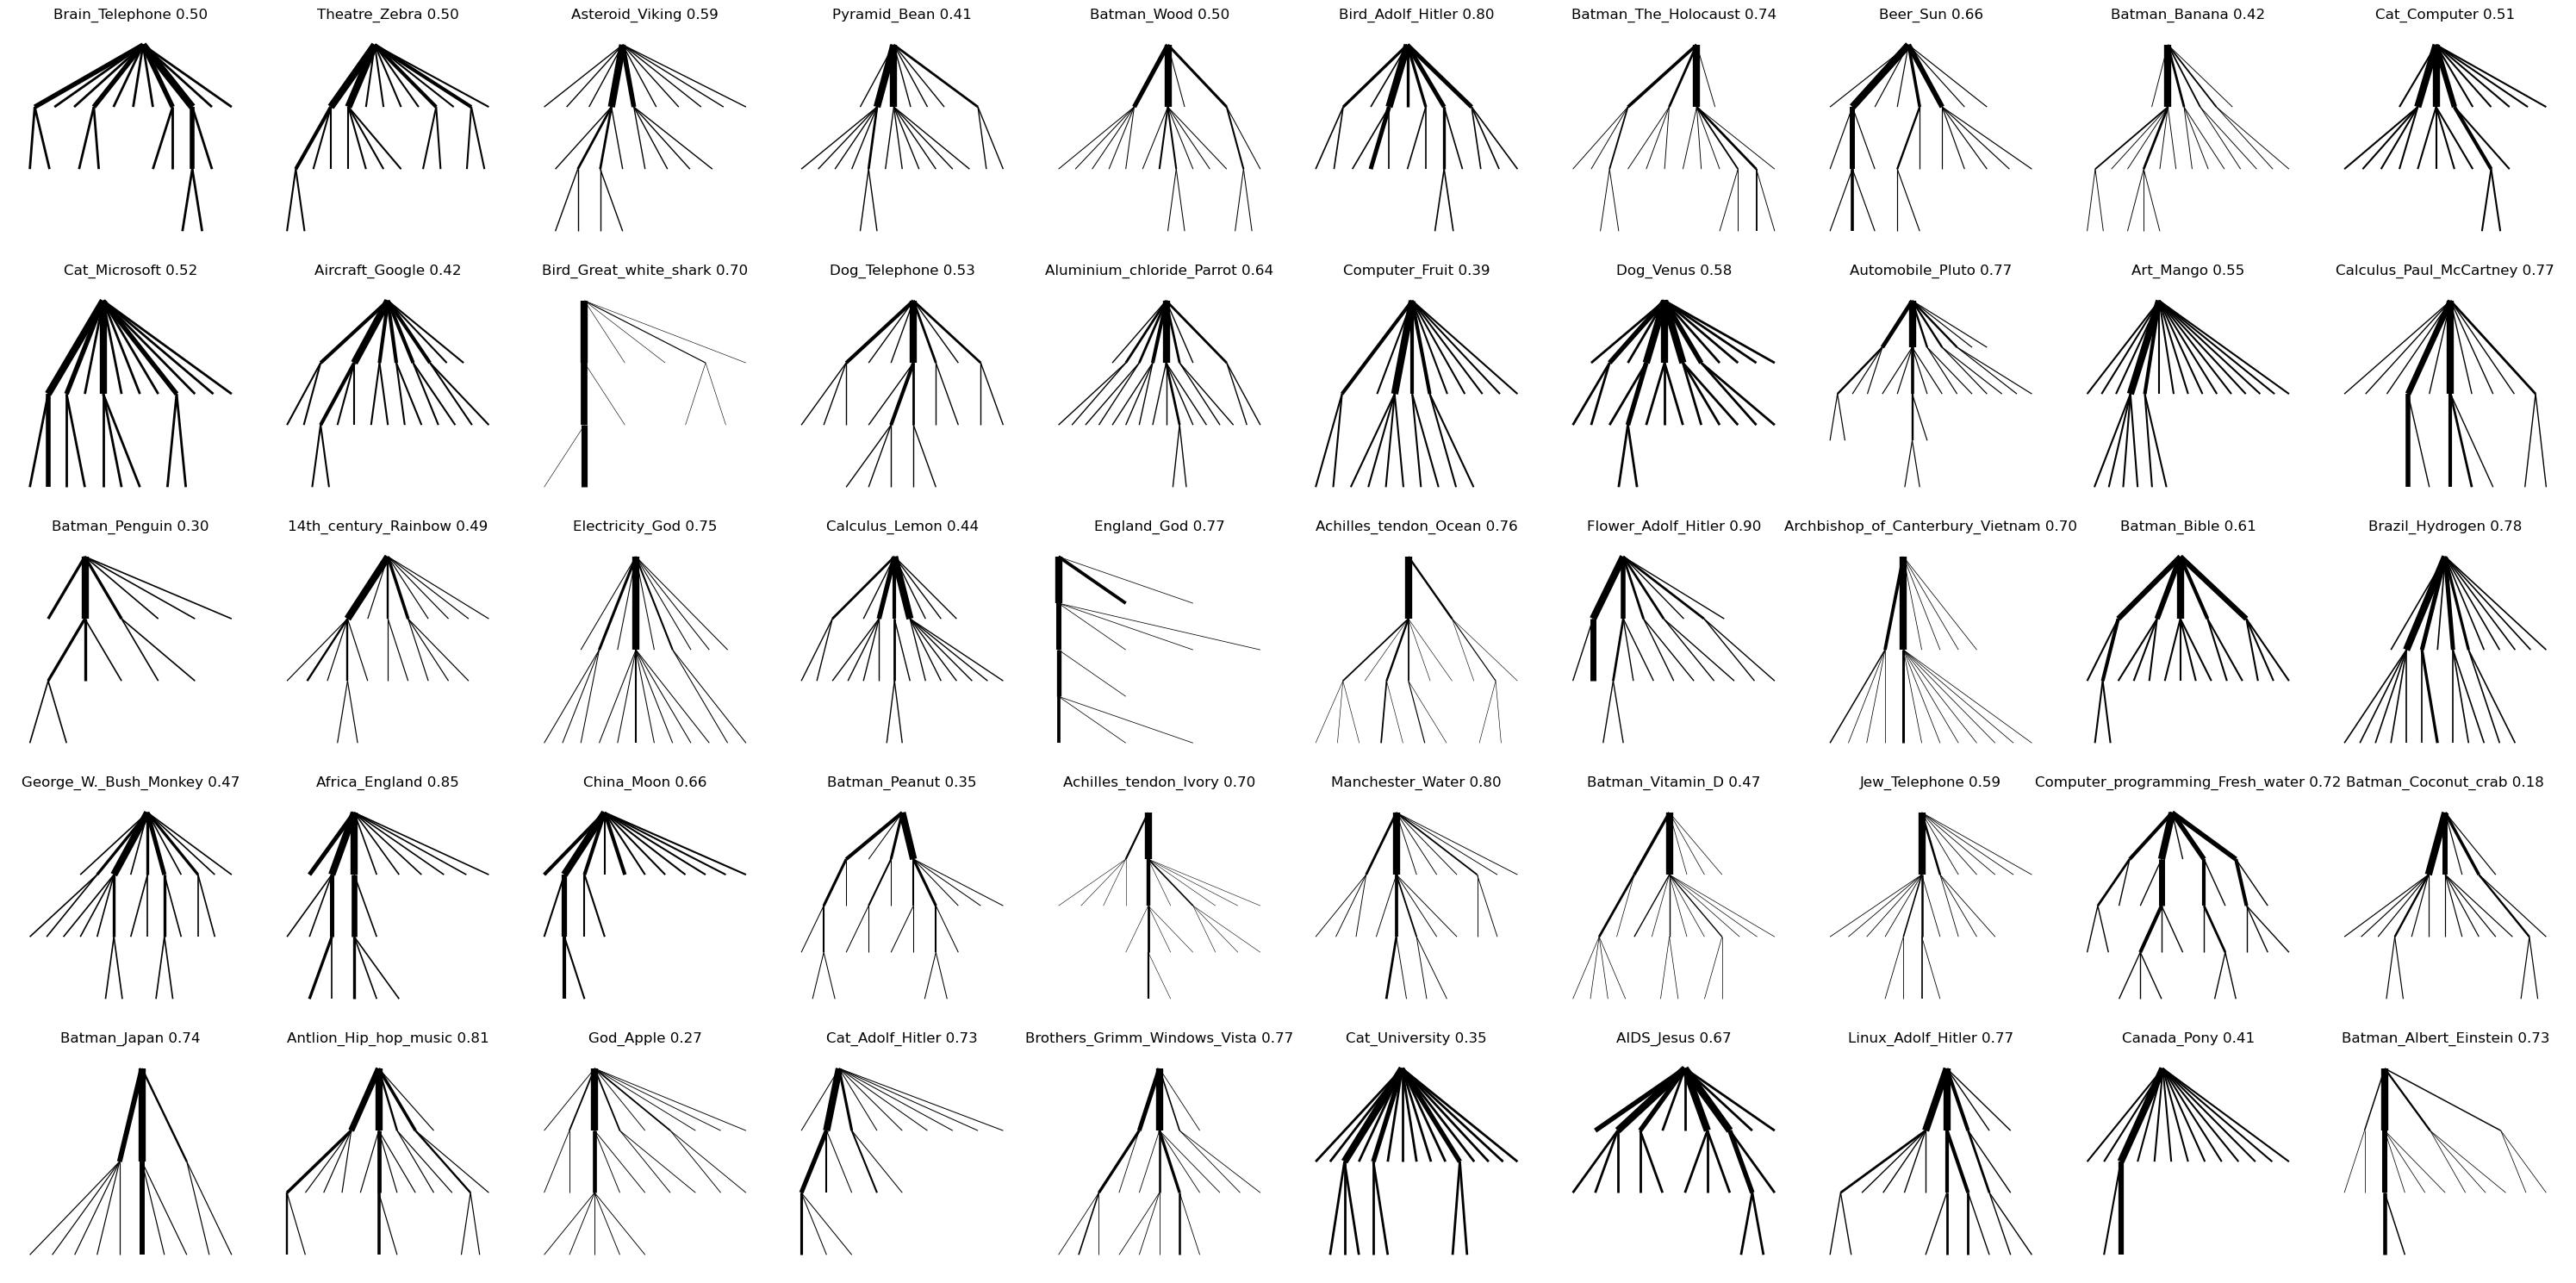

In [497]:
n_cols = 10
fig, axes = plt.subplots(
    5, n_cols, figsize=(30, 15)
)  # , facecolor=hex_to_rgb_add_alpha("FF5A5F", 0.3))
for i, (start_end) in enumerate(most_common_paths):
    G = trees_by_path[start_end][0]

    ax = axes[i // n_cols][i % n_cols]
    plot_flow_tree(G, f"{start_end} {accs[i]:.2f}", ax, just_edges=True, no_title=False)

plt.tight_layout()
plt.savefig("figures/wikispeedia/most_common_paths_wikispeedia.png")
plt.show()

Group 1 mean: 5.20 (var=0.71; n=130)
Group 2 mean: 4.99 (var=0.94; n=120)
T-statistic: 1.8066, P-value: 0.0720
(0.20833333333333393, 0.1456)


/opt/miniconda3/envs/mazedyn-test/lib/python3.11/site-packages/karateclub/estimator.py:63: UserWarning: Please do be advised that the graph you have provided does not contain (some) edges in the main diagonal, for instance the self-loop constitued of (0, 0). These selfloops are necessary to ensure that the graph is traversable, and for this reason we create a copy of the graph and add therein the missing edges. Since we are creating a copy, this will immediately duplicate the memory requirements. To avoid this double allocation, you can provide the graph with the selfloops.
  warnings.warn(



Hypothesis Test Results:
                                                               hypothesis    test_type   group1_name  group2_name  group1_mean  group2_mean  group1_var  group2_var  group1_n  group2_n  statistic   p_value  significant                metric                                                                                    notes
0   Flow Trees of easier paths are different from those from harder ones.       t-test  better trees  worse trees    21.015385    22.016667   13.030533    9.833056       130       120  -2.323464  0.020963         True             num_nodes                       Comparing flow tree num_nodes between better trees and worse trees
1   Flow Trees of easier paths are different from those from harder ones.  permutation  better trees  worse trees    21.015385    22.016667   13.030533    9.833056       130       120   1.001282  0.045000         True             num_nodes             Permutation test on flow tree num_nodes between better trees and

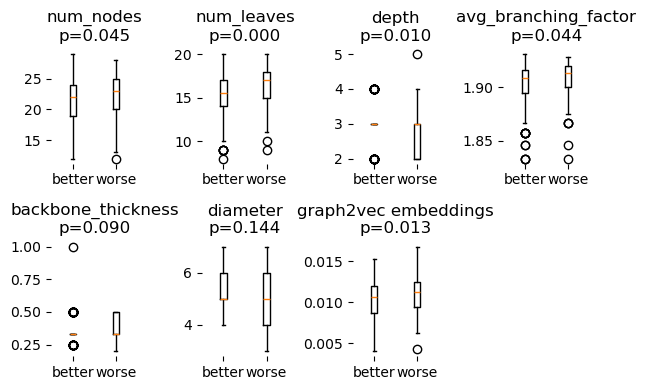

/var/folders/24/lp6939qs6f1d149198s_3mv40000gn/T/ipykernel_94260/2186228644.py:63: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results_df = pd.concat([all_results_df, results_df], ignore_index=True)


In [17]:
import karateclub as kc

# Accuracy makes different
mean_acc = np.mean(accs)

better_trees, better_tree_diameters = [], []
worse_trees, worse_tree_diameters = [], []

for i, start_end in enumerate(most_common_paths):
    # this_df = trajs_df[(trajs_df["StartEnd"]==start_end)]
    these_diameters = [nx.diameter(trees_by_path[start_end][j]) for j in range(k_fold)]
    if accs[i] > mean_acc:
        better_tree_diameters.extend(these_diameters)
        better_trees.extend(trees_by_path[start_end])
    else:
        worse_tree_diameters.extend(these_diameters)
        worse_trees.extend(trees_by_path[start_end])

group1, group2 = better_tree_diameters, worse_tree_diameters
t_stat, p_value = stats.ttest_ind(group1, group2)
print(
    f"Group 1 mean: {np.mean(group1):.2f} (var={np.var(group1):.2f}; n={len(group1)})"
)
print(
    f"Group 2 mean: {np.mean(group2):.2f} (var={np.var(group2):.2f}; n={len(group2)})"
)
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")
print(run_homemade_permutation_test(group1, group2))


results_df = get_new_results_df()

# Run comparison on quartile groups
results_df, q12_features, q34_features = compare_flow_tree_groups(
    results_df,
    better_trees,
    worse_trees,
    group1_name="better trees",
    group2_name="worse trees",
    hypothesis_test_types=["t-test", "permutation"],
    hypothesis="Flow Trees of easier paths are different from those from harder ones.",
)

# Display results
print("\nHypothesis Test Results:")
print(results_df.to_string())

# Create visualization of results
plt.figure(figsize=(6, 4))
for i, feature_name in enumerate(results_df["metric"].unique()):
    feature_results = results_df[results_df["metric"] == feature_name]
    perm_result = feature_results[feature_results["test_type"] == "permutation"].iloc[0]

    plt.subplot(2, 4, i + 1)
    plt.boxplot([q12_features[:, i], q34_features[:, i]], labels=["better", "worse"])
    plt.title(f"{feature_name}\np={perm_result['p_value']:.3f}")
    # if perm_result["significant"]:
    # plt.gca().set_facecolor('lightgreen')
    plt.box(on=None)
plt.tight_layout()
plt.show()

all_results_df = pd.concat([all_results_df, results_df], ignore_index=True)


1. aspects of graph structure
- centrality

2. start vs. end
- reverse 


is 2nd node more general than 1st node?


level of word based on usage / frequency


questions about semantics and questions about graph structure


alphabet (more specific vs more general)


r experienced people the backbone people or more specific? do they branch less? more successful?


branchiness of FT node vs semantic specificity of node

when do they take steps semantically closer? when do they backstep? why

how do people use wikipedia to do searches

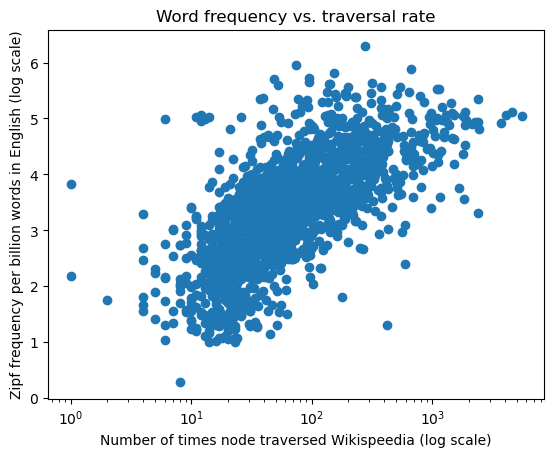

Zipf correlation: 0.683, p=0.000


In [18]:
node_counts = {}
for trajectory in trajs_df.traj:
    for node in trajectory:
        node_counts[node] = node_counts.get(node, 0) + 1

sorted_nodes = sorted(node_counts.keys(), key=lambda x: node_counts[x], reverse=True)

wikispeedia_counts, zipf_frequencies = [], []
for node in sorted_nodes:
    # print(node, zipf_frequency(node, "en"))
    zf = zipf_frequency(node, "en")
    if zf > 0:
        wikispeedia_counts.append(node_counts[node])
        zipf_frequencies.append(zf)


plt.scatter(wikispeedia_counts, zipf_frequencies)
plt.xscale("log")
plt.xlabel("Number of times node traversed Wikispeedia (log scale)")
plt.ylabel("Zipf frequency per billion words in English (log scale)")
plt.title("Word frequency vs. traversal rate")
plt.show()

corr_zipf, p_value_zipf = pearsonr(np.log(wikispeedia_counts), zipf_frequencies)
print(f"Zipf correlation: {corr_zipf:.3f}, p={p_value_zipf:.3f}")

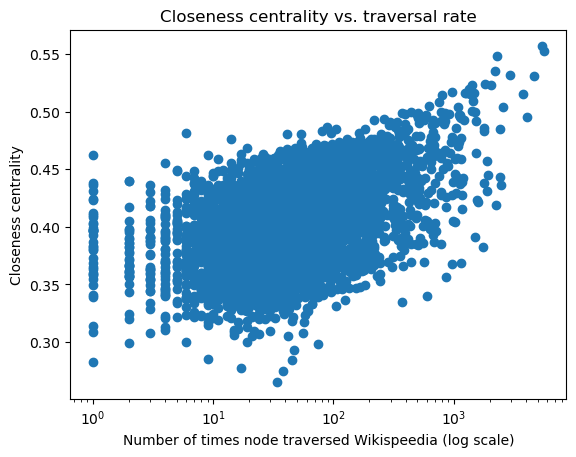

Closeness centrality correlation: 0.486, p=0.000


In [19]:
# wikispeedia_counts, closeness_centralities = [], []
# for node in sorted_nodes:
#     if node not in closeness_centrality:
#         continue
#     if (node_counts[node] > 10000) or (node_counts[node] < 1):
#         continue
#     wikispeedia_counts.append(node_counts[node])
#     closeness_centralities.append(closeness_centrality[node])


# plt.scatter(wikispeedia_counts, closeness_centralities)
# plt.xscale("log")
# plt.xlabel("Number of times node traversed Wikispeedia (log scale)")
# plt.ylabel("Closeness centrality")
# plt.title("Closeness centrality vs. traversal rate")
# plt.show()

# corr_close, p_value_close = pearsonr(np.log(wikispeedia_counts), closeness_centralities)
# print(f"Closeness centrality correlation: {corr_close:.3f}, p={p_value_close:.3f}")

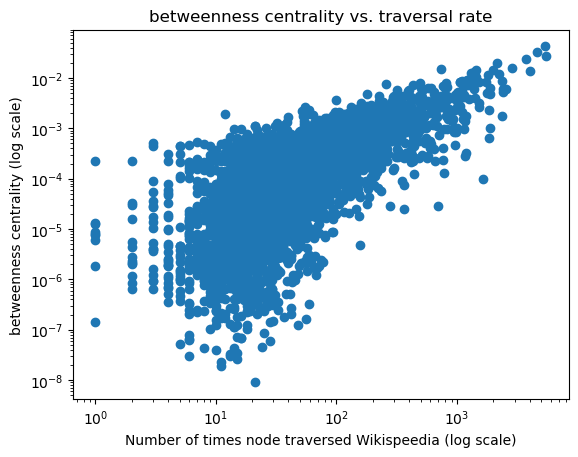

Betweenness centrality correlation: 0.692, p=0.000


In [19]:
wikispeedia_counts, betweenness_centralities = [], []
for node in sorted_nodes:
    if node not in betweenness_centrality:
        continue
    if node_counts[node] > 10000:
        continue
    if betweenness_centrality[node] == 0:
        continue
    wikispeedia_counts.append(node_counts[node])
    betweenness_centralities.append(betweenness_centrality[node])


plt.scatter(wikispeedia_counts, betweenness_centralities)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of times node traversed Wikispeedia (log scale)")
plt.ylabel("betweenness centrality (log scale)")
plt.title("betweenness centrality vs. traversal rate")
plt.show()

corr_between, p_value_between = pearsonr(
    np.log(wikispeedia_counts), np.log(betweenness_centralities)
)
print(
    f"Betweenness centrality correlation: {corr_between:.3f}, p={p_value_between:.3f}"
)

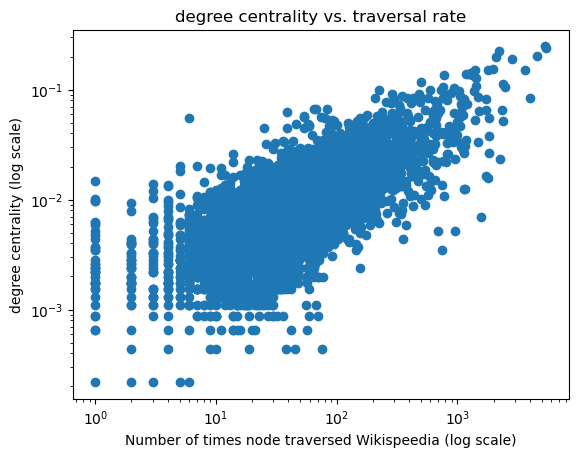

Degree centrality correlation: 0.704, p=0.000


In [425]:
wikispeedia_counts, degree_centralities = [], []
for node in sorted_nodes:
    if node not in degree_centrality:
        continue
    if node_counts[node] > 10000:
        continue
    wikispeedia_counts.append(node_counts[node])
    degree_centralities.append(degree_centrality[node])


plt.scatter(wikispeedia_counts, degree_centralities)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of times node traversed Wikispeedia (log scale)")
plt.ylabel("degree centrality (log scale)")
plt.title("degree centrality vs. traversal rate")
plt.show()

corr_degree, p_value_degree = pearsonr(
    np.log(wikispeedia_counts), np.log(degree_centralities)
)
print(f"Degree centrality correlation: {corr_degree:.3f}, p={p_value_degree:.3f}")

r12=0.681, r13=0.736, r23=0.603
Z=-4.06981, p=0.00002


### Sentence embeddings

In [21]:
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

# pip install "tokenizers<0.22" --force-reinstall
model_name = "bert-base-uncased"
tok = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)


def embed(text):
    tokens = tok(text, return_tensors="pt", truncation=True)
    out = model(**tokens)
    # mean pooling
    emb = out.last_hidden_state.mean(dim=1)
    return emb.detach()


def cosine(a, b):
    return F.cosine_similarity(a, b).item()


def get_topic_distance(topic1, topic2):
    return cosine(embed(topic1), embed(topic2))


print(embed("China").shape)

torch.Size([1, 768])


In [22]:
# topics = [node.replace("_", " ") for (start, target) in most_common_paths]
print(
    most_common_paths[0][0],
    most_common_paths[0][1],
    get_topic_distance(most_common_paths[0][0], most_common_paths[0][1]),
)
print(
    most_common_paths[30][0],
    most_common_paths[30][1],
    get_topic_distance(most_common_paths[30][0], most_common_paths[30][1]),
)

B r 0.7538877725601196
G e 0.9034019112586975


## Node Flow Trees
including intermediate nodes

In [23]:
node_counts = {}
for _, row in trajs_df.iterrows():
    for article in row.traj:
        node_counts[article] = node_counts.get(article, 0) + 1

In [24]:
# find most common nodes
k = 100
most_common_nodes = sorted(
    [x for x in node_counts], key=lambda x: node_counts[x], reverse=True
)[:k]

print(
    f"Most common node is {most_common_nodes[0]} with {node_counts[most_common_nodes[0]]} attempts."
)
print(
    f"{k}th most common node is {most_common_nodes[-1]} with {node_counts[most_common_nodes[-1]]} attempts"
)


Most common node is United_States with 12660 attempts.
100th most common node is Electricity with 670 attempts


In [25]:
# find most start common nodes
k = 100
most_common_start_nodes = trajs_df["StartAt"].value_counts()[:k].index.tolist()

print(
    f"Most common start node is {most_common_start_nodes[0]} with {len(trajs_df[trajs_df['StartAt'] == most_common_start_nodes[0]]['traj'])} attempts."
)
print(
    f"{k}th most common start node is {most_common_start_nodes[-1]} with {len(trajs_df[trajs_df['StartAt'] == most_common_start_nodes[-1]]['traj'])} attempts"
)

reduced_trajs_df = trajs_df[trajs_df["StartAt"].isin(most_common_start_nodes)].copy()

Most common start node is Brain with 1909 attempts.
100th most common start node is Cattle with 40 attempts


In [ ]:
## Make node trees for everything
# Create empty DataFrame to store all tree information
all_tree_df = pd.DataFrame(
    columns=[
        "node",  # the actual node label
        "trees",  # list of bootstrapped trees
    ]
)

example_tree_by_start_node = {}

traj_dict = {x: [] for x in most_common_nodes}
for traj in trajs_df.traj:
    for i in range(len(traj) - 6):  # want min path length 5?
        if traj[i] in most_common_nodes:
            traj_dict[traj[i]].append(traj[i : i + 5])

print(np.min([len(traj_dict[x]) for x in traj_dict]))
# print (traj_dict)
k_fold = 20
for node in traj_dict:
    trees = []
    for _ in range(k_fold):
        sampled_trajs = traj_dict[node]
        # print(len(sampled_trajs))
        if len(sampled_trajs) > 20:
            sampled_indices = np.random.choice(
                len(sampled_trajs), size=20, replace=False
            )
            sampled_trajs = [sampled_trajs[i] for i in sampled_indices]
        else:
            print(len(sampled_trajs))
        G = generate_flow_tree_from_trajs(sampled_trajs, END_NODE="1")
        new_G = nx.relabel.convert_node_labels_to_integers(
            G, first_label=0, ordering="default"
        )
        trees.append(new_G)

    example_tree_by_start_node[node] = trees[0]
    # print(trees)

    all_tree_df = pd.concat(
        [
            all_tree_df,
            pd.DataFrame(
                {"node": [(node,)] * len(trees), "trees": trees, "type": "start"}
            ),
        ],
        ignore_index=True,
    )

all_tree_df

22


,node,trees,type
0,"(United_States,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start
1,"(United_States,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start
2,"(United_States,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start
3,"(United_States,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start
4,"(United_States,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start
...,...,...,...
1995,"(Electricity,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start
1996,"(Electricity,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start
1997,"(Electricity,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start
1998,"(Electricity,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start


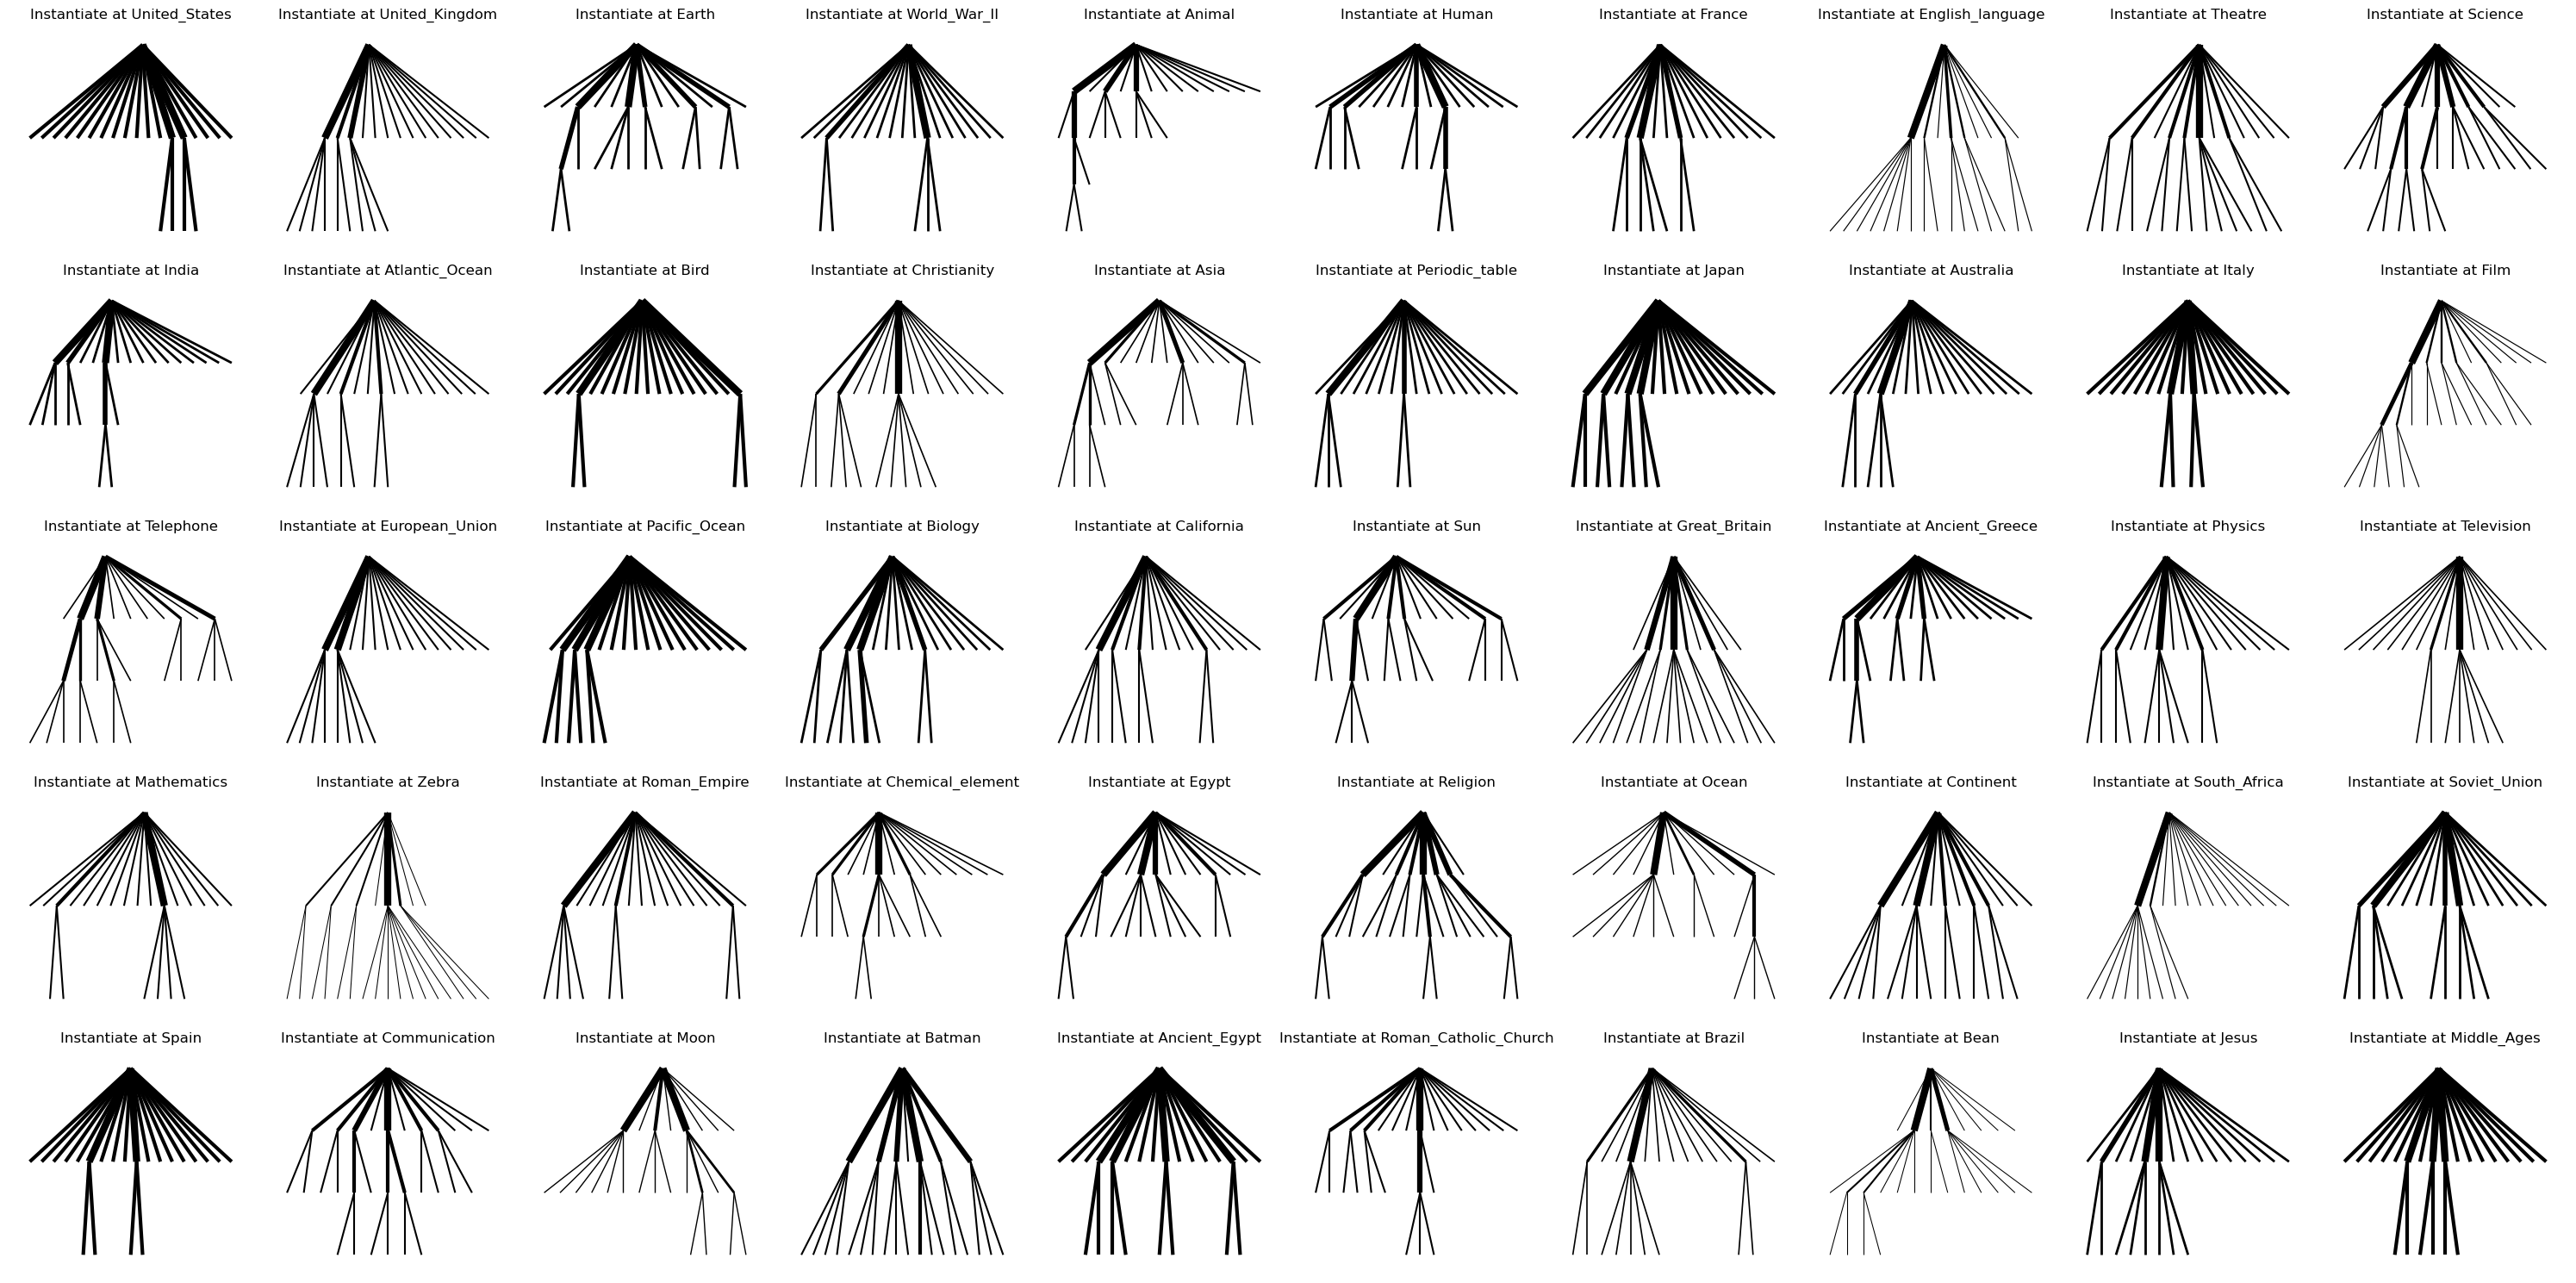

In [27]:
n_cols = 10
fig, axes = plt.subplots(
    5, n_cols, figsize=(30, 15)
)  # , facecolor=hex_to_rgb_add_alpha("FF5A5F", 0.3))
for j, node in enumerate(most_common_nodes):
    if j % 2 != 0:
        continue
    i = j // 2

    G = example_tree_by_start_node[node]
    ax = axes[i // n_cols][i % n_cols]
    plot_flow_tree(G, f"Instantiate at {node}", ax, just_edges=True, no_title=False)

plt.tight_layout()
plt.savefig("figures/wikispeedia/most_common_nodes_wikispeedia_START.png")
plt.show()

### Reverse End Node

In [32]:
example_tree_by_end_node = {}

rev_traj_dict = {x: [] for x in most_common_nodes}
for traj in trajs_df.traj:
    for i in range(5, len(traj)):  # want min path length 7?
        if traj[i] in most_common_nodes:
            rev_traj = [x for x in reversed(traj[i - 5 : i])]
            rev_traj_dict[traj[i]].append(rev_traj)


for node in rev_traj_dict:
    trees = []
    for _ in range(k_fold):
        sampled_trajs = rev_traj_dict[node]
        if len(sampled_trajs) < 10:
            continue
        # print(len(sampled_trajs))
        if len(sampled_trajs) > 20:
            sampled_indices = np.random.choice(
                len(sampled_trajs), size=20, replace=False
            )
            sampled_trajs = [sampled_trajs[i] for i in sampled_indices]
        else:
            print(len(sampled_trajs))
        G = generate_flow_tree_from_trajs(sampled_trajs, END_NODE="1")
        new_G = nx.relabel.convert_node_labels_to_integers(
            G, first_label=0, ordering="default"
        )
        trees.append(new_G)

    example_tree_by_end_node[node] = trees[0]

    all_tree_df = pd.concat(
        [
            all_tree_df,
            pd.DataFrame(
                {"node": [(node,)] * len(trees), "trees": trees, "type": "rev_end"}
            ),
        ],
        ignore_index=True,
    )

all_tree_df

,node,trees,type
0,"(United_States,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start
1,"(United_States,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start
2,"(United_States,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start
3,"(United_States,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start
4,"(United_States,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start
...,...,...,...
3995,"(Electricity,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",rev_end
3996,"(Electricity,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",rev_end
3997,"(Electricity,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",rev_end
3998,"(Electricity,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",rev_end


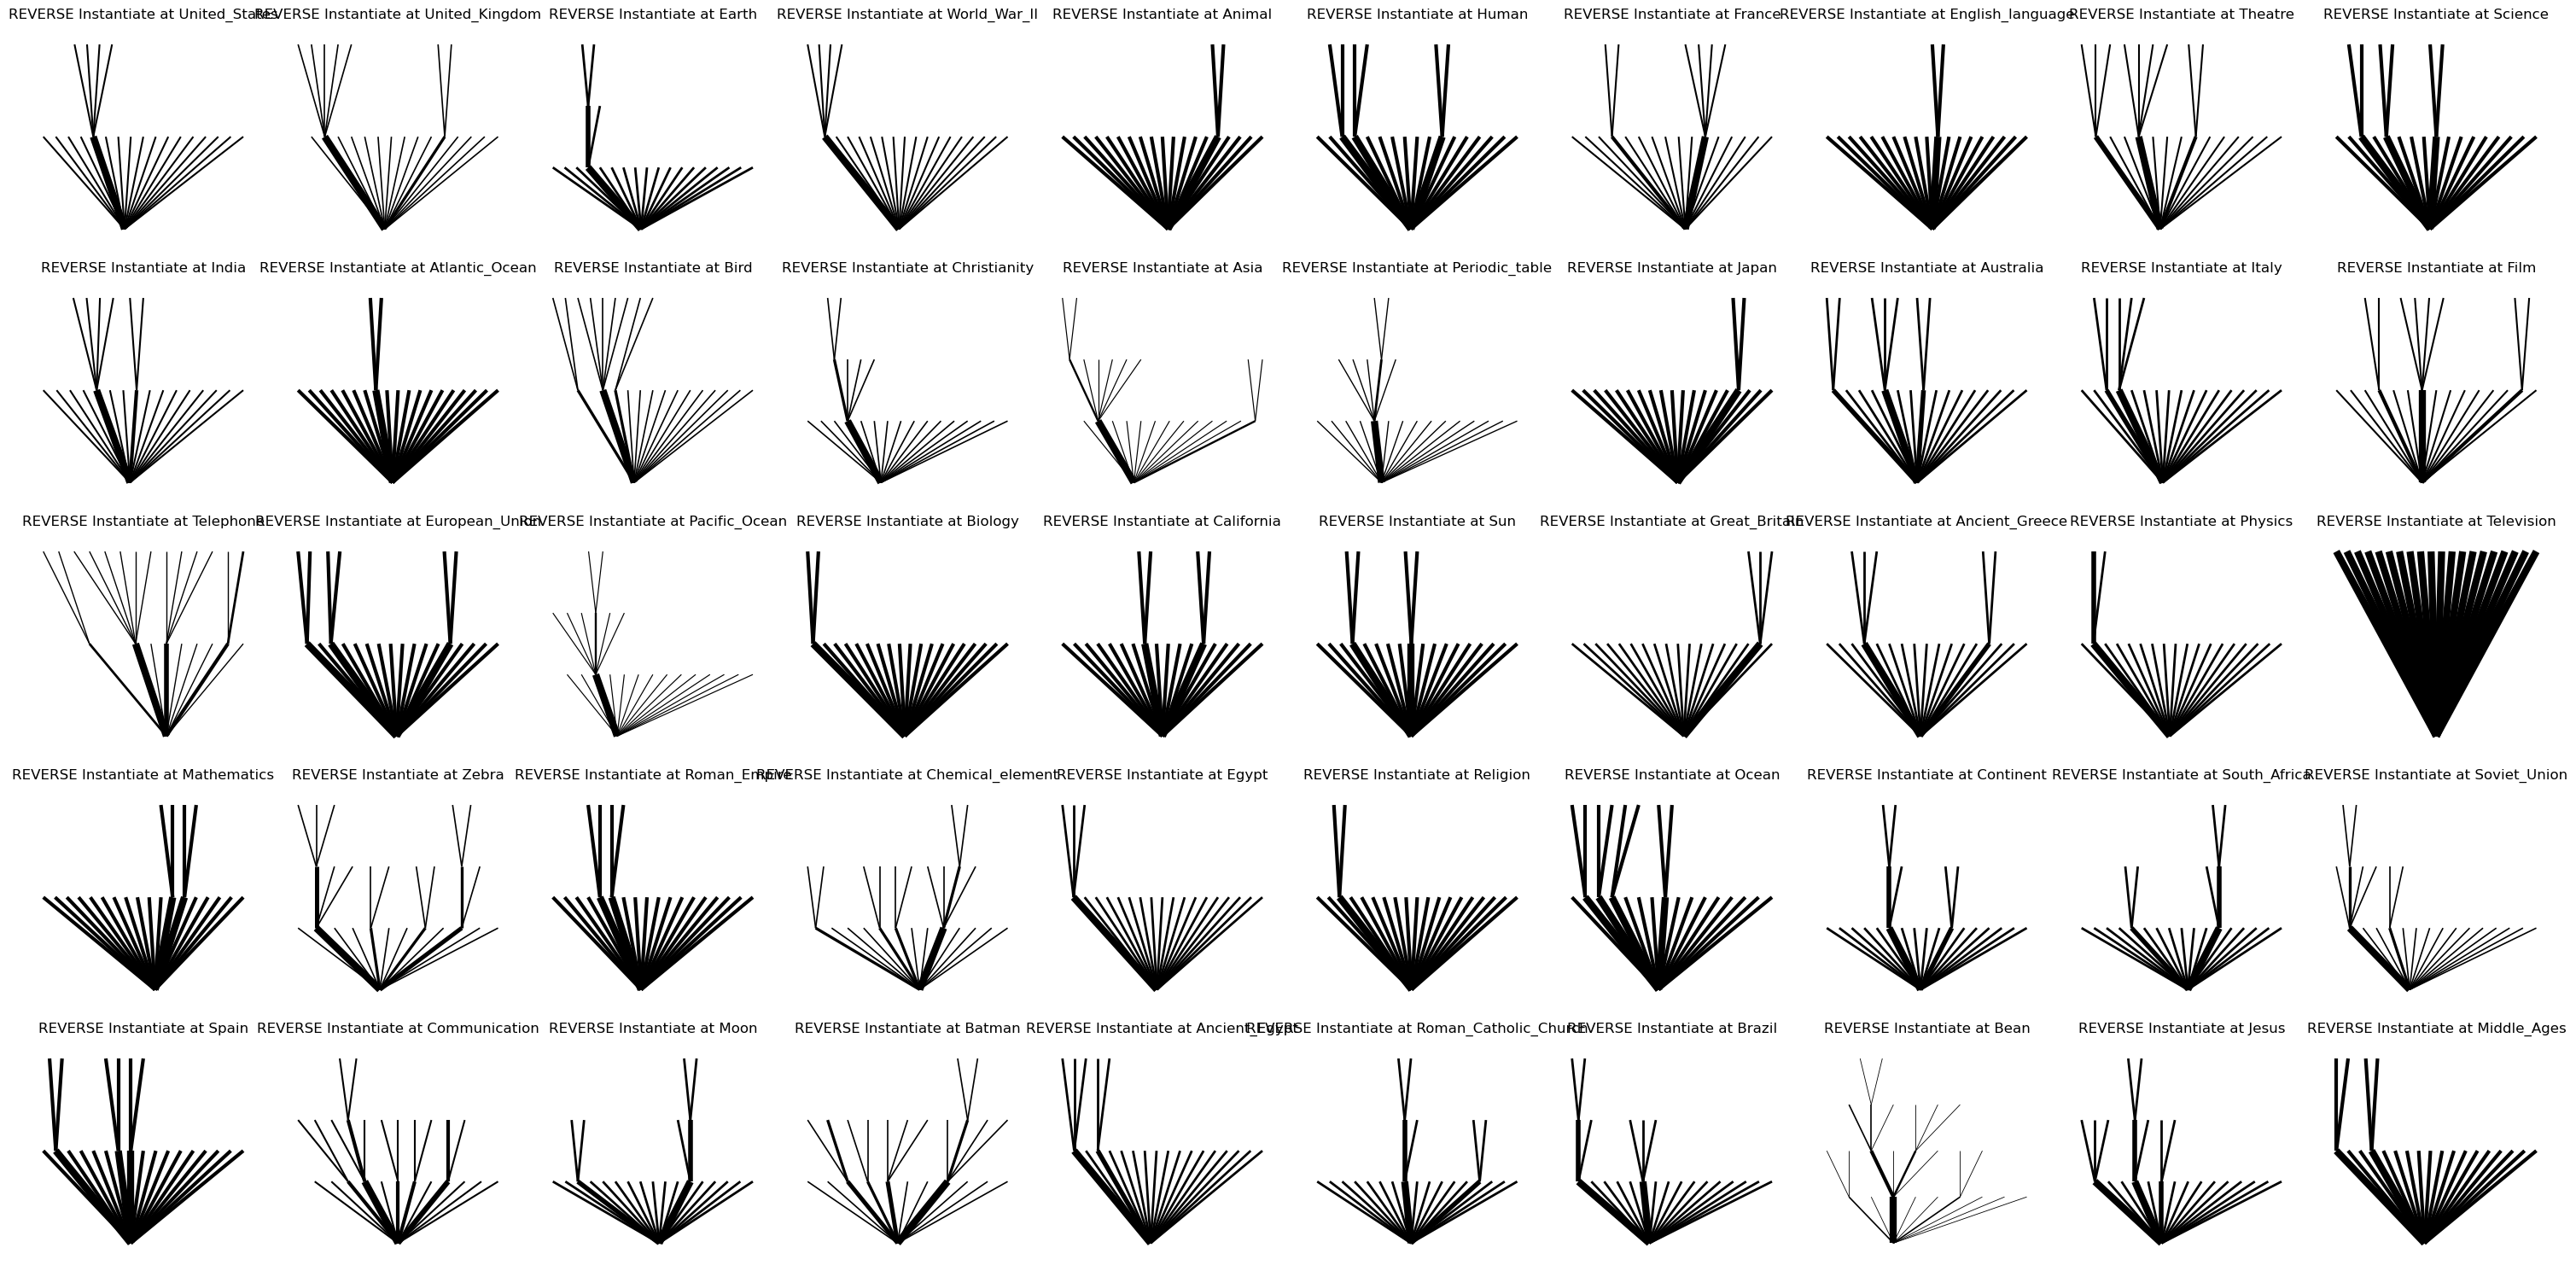

In [34]:
n_cols = 10
fig, axes = plt.subplots(5, n_cols, figsize=(30, 15))
for j, node in enumerate(most_common_nodes):
    if j % 2 != 0:
        continue
    i = j // 2

    G = example_tree_by_end_node[node]
    ax = axes[i // n_cols][i % n_cols]
    plot_flow_tree(
        G, f"REVERSE Instantiate at {node}", ax, just_edges=True, no_title=False
    )
    ax.yaxis.set_inverted(True)

plt.tight_layout()
plt.savefig("figures/wikispeedia/most_common_nodes_wikispeedia_END.png")
plt.show()

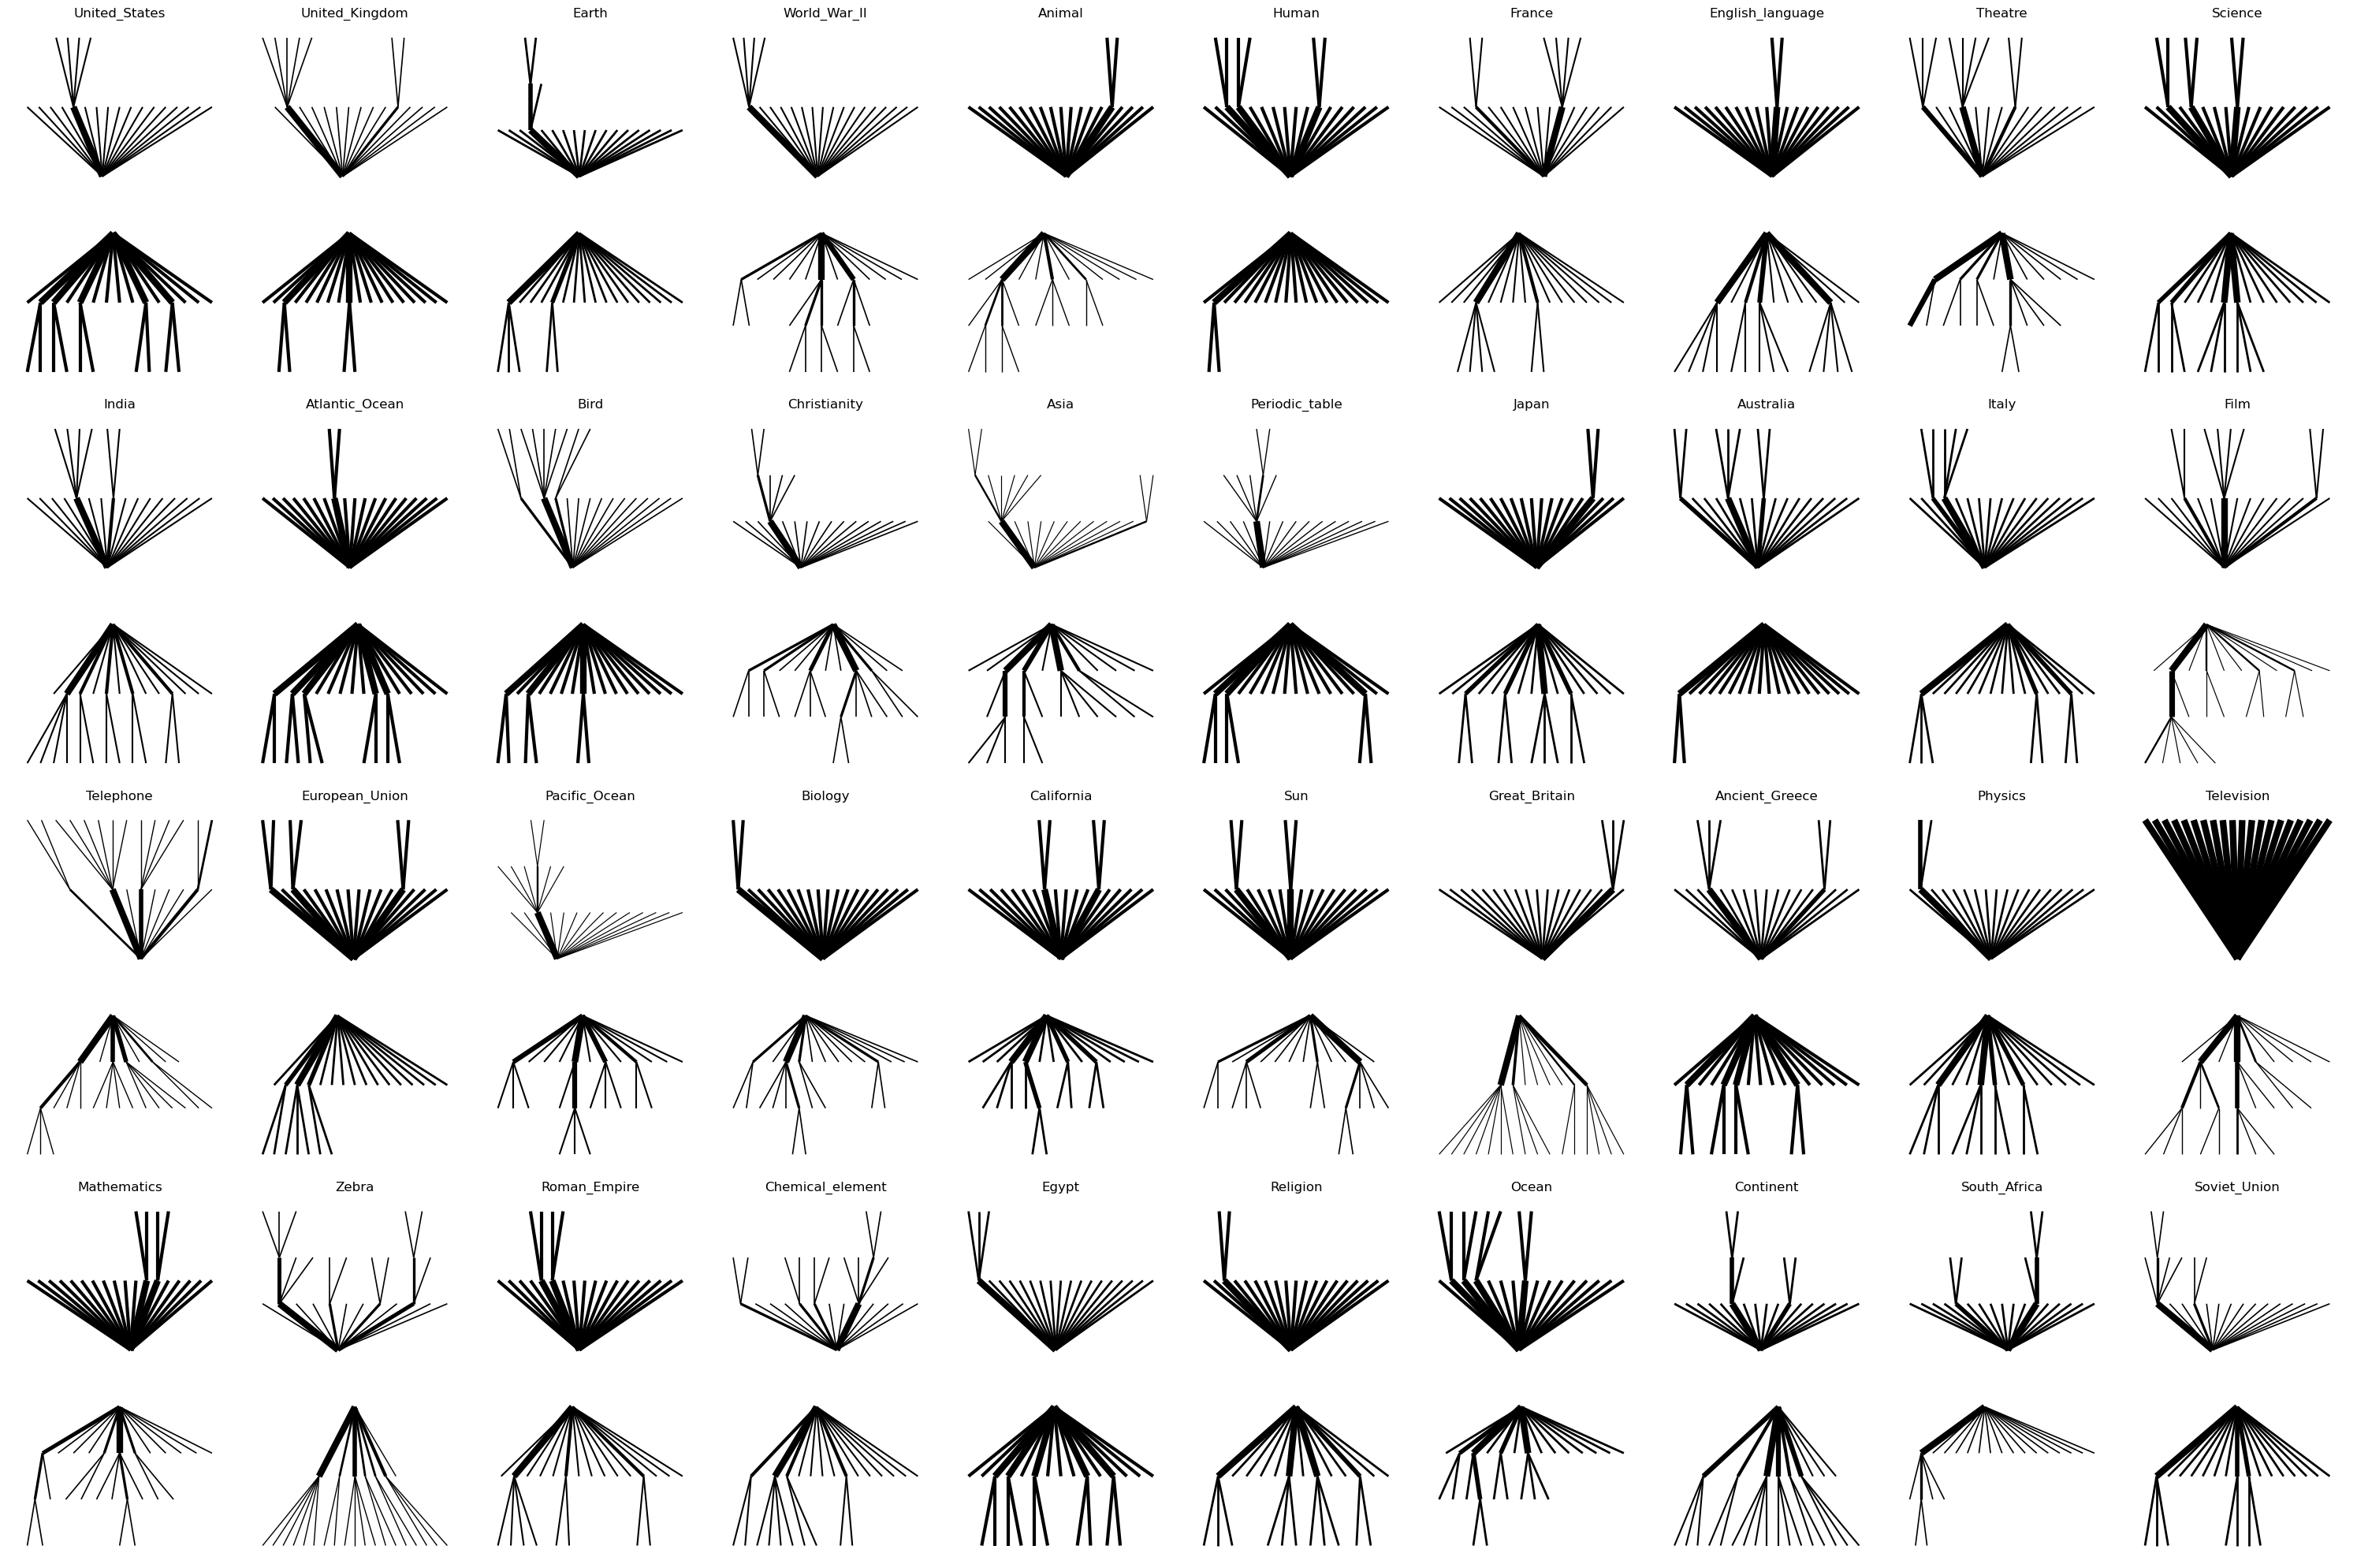

In [39]:
fig, axes = plt.subplots(8, 10, figsize=(30, 20))
for j, node in enumerate(most_common_nodes):
    if j % 2 != 0:
        continue
    i = j // 2

    ax = axes[2 * (i // 10)][i % 10]
    G = example_tree_by_end_node[node]
    plot_flow_tree(G, f"{node}", ax, just_edges=True, no_title=False)
    ax.invert_yaxis()

    ax = axes[2 * (i // 10) + 1][i % 10]
    G = example_tree_by_start_node[node]
    plot_flow_tree(G, f"Instantiate at {node}", ax, just_edges=True, no_title=True)

    if i == 39:
        break

plt.tight_layout()
plt.savefig("figures/wikispeedia/10_most_common_nodes_wikispeedia_STARTEND.png")
plt.show()

In [46]:
all_tree_df

,node,trees,type
0,"(United_States,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start
1,"(United_States,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start
2,"(United_States,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start
3,"(United_States,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start
4,"(United_States,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start
...,...,...,...
3995,"(Electricity,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",rev_end
3996,"(Electricity,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",rev_end
3997,"(Electricity,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",rev_end
3998,"(Electricity,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",rev_end


/opt/miniconda3/envs/mazedyn-test/lib/python3.11/site-packages/karateclub/estimator.py:63: UserWarning: Please do be advised that the graph you have provided does not contain (some) edges in the main diagonal, for instance the self-loop constitued of (0, 0). These selfloops are necessary to ensure that the graph is traversable, and for this reason we create a copy of the graph and add therein the missing edges. Since we are creating a copy, this will immediately duplicate the memory requirements. To avoid this double allocation, you can provide the graph with the selfloops.
  warnings.warn(



Hypothesis Test Results:
                                            hypothesis    test_type group1_name group2_name  group1_mean  group2_mean  group1_var  group2_var  group1_n  group2_n  statistic        p_value  significant                metric                                                                         notes
0   Flow from a node is different than flow to a node.       t-test       start     rev_end    25.207000    23.537000    2.888151    1.836631      2000      2000  34.350414  8.013065e-227         True             num_nodes                       Comparing flow tree num_nodes between start and rev_end
1   Flow from a node is different than flow to a node.  permutation       start     rev_end    25.207000    23.537000    2.888151    1.836631      2000      2000   1.670000   2.000000e-04         True             num_nodes             Permutation test on flow tree num_nodes between start and rev_end
2   Flow from a node is different than flow to a node.       t-test    

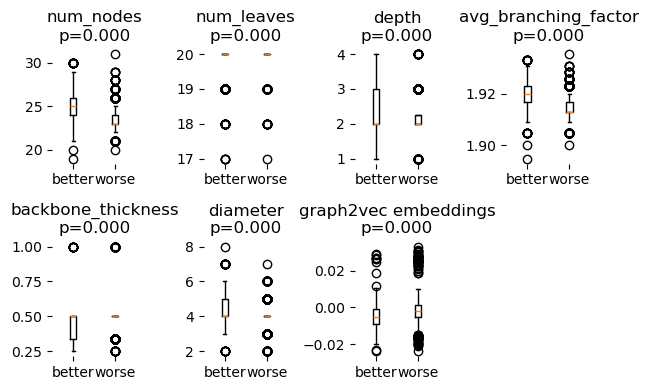

In [54]:
# Start v rev end

start_trees = []
rev_end_trees = []

for i, node in enumerate(most_common_nodes):
    start_trees.extend(
        [
            x
            for x in all_tree_df[
                (all_tree_df.node == (node,)) & (all_tree_df.type == "start")
            ].trees.to_numpy()
        ]
    )
    rev_end_trees.extend(
        [
            x
            for x in all_tree_df[
                (all_tree_df.node == (node,)) & (all_tree_df.type == "rev_end")
            ].trees.to_numpy()
        ]
    )

results_df = get_new_results_df()
results_df, q12_features, q34_features = compare_flow_tree_groups(
    results_df,
    start_trees,
    rev_end_trees,
    group1_name="start",
    group2_name="rev_end",
    hypothesis_test_types=["t-test", "permutation"],
    hypothesis="Flow from a node is different than flow to a node.",
)

# Display results
print("\nHypothesis Test Results:")
print(results_df.to_string())

# Create visualization of results
plt.figure(figsize=(6, 4))
for i, feature_name in enumerate(results_df["metric"].unique()):
    feature_results = results_df[results_df["metric"] == feature_name]
    perm_result = feature_results[feature_results["test_type"] == "permutation"].iloc[0]
    print(perm_result[["metric", "group1_mean", "group2_mean"]])
    plt.subplot(2, 4, i + 1)
    plt.boxplot([q12_features[:, i], q34_features[:, i]], labels=["better", "worse"])
    plt.title(f"{feature_name}\np={perm_result['p_value']:.3f}")
    # if perm_result["significant"]:
    # plt.gca().set_facecolor('lightgreen')
    plt.box(on=None)
plt.tight_layout()
plt.show()

In [55]:
# In degree v out degree v FT degree
print(wikiG.out_edges("United_States"))
print(wikiG.in_edges("United_States"))

all_tree_df["in_degree"] = all_tree_df.node.apply(lambda x: len(wikiG.in_edges(x[0])))
all_tree_df["out_degree"] = all_tree_df.node.apply(lambda x: len(wikiG.out_edges(x[0])))

all_tree_df["log_in_out"] = np.log(
    (1 + all_tree_df["in_degree"]) / (1 + all_tree_df["out_degree"])
)

all_tree_df["ft_degree"] = all_tree_df.trees.apply(
    lambda x: len(list(x.neighbors(list(x.nodes())[0])))
)

# print(all_tree_df.type.unique())

# tr = all_tree_df.iloc[0]["trees"]
# for node in tr.nodes():
#     print(node)
#     print(list(tr.neighbors(node)))

all_tree_df

[('United_States', 'Abraham_Lincoln'), ('United_States', 'Advertising'), ('United_States', 'Agriculture'), ('United_States', 'American_Civil_War'), ('United_States', 'American_English'), ('United_States', 'American_Revolutionary_War'), ('United_States', 'American_Samoa'), ('United_States', 'American_football'), ('United_States', 'American_popular_music'), ('United_States', 'Amtrak'), ('United_States', 'Anguilla'), ('United_States', 'Antarctica'), ('United_States', 'Antigua_and_Barbuda'), ('United_States', 'Apollo_11'), ('United_States', 'Arctic_Ocean'), ('United_States', 'Argentina'), ('United_States', 'Aruba'), ('United_States', 'Atlanta%2C_Georgia'), ('United_States', 'Atlantic_Ocean'), ('United_States', 'Attack_on_Pearl_Harbor'), ('United_States', 'Auto_racing'), ('United_States', 'Bah%C3%A1%27%C3%AD_Faith'), ('United_States', 'Baker_Island'), ('United_States', 'Bald_Eagle'), ('United_States', 'Baltimore%2C_Maryland'), ('United_States', 'Barbados'), ('United_States', 'Baseball'), ('

,node,trees,type,in_degree,out_degree,log_in_out,ft_degree
0,"(United_States,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start,1551,294,1.660324,15
1,"(United_States,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start,1551,294,1.660324,18
2,"(United_States,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start,1551,294,1.660324,16
3,"(United_States,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start,1551,294,1.660324,19
4,"(United_States,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start,1551,294,1.660324,18
...,...,...,...,...,...,...,...
3995,"(Electricity,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",rev_end,109,38,1.036919,18
3996,"(Electricity,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",rev_end,109,38,1.036919,17
3997,"(Electricity,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",rev_end,109,38,1.036919,17
3998,"(Electricity,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",rev_end,109,38,1.036919,17


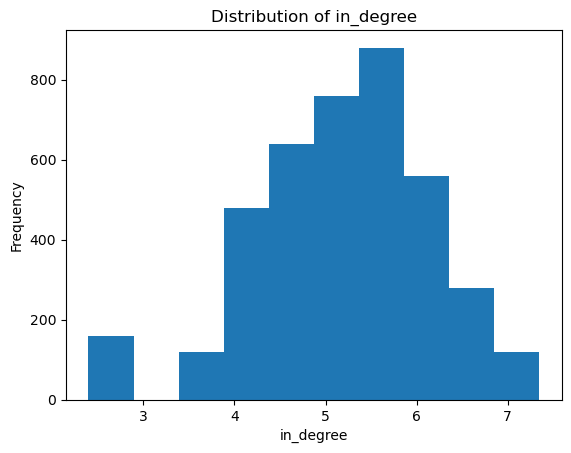

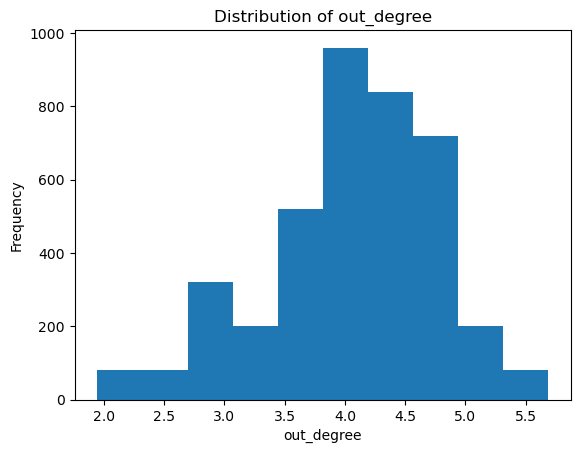

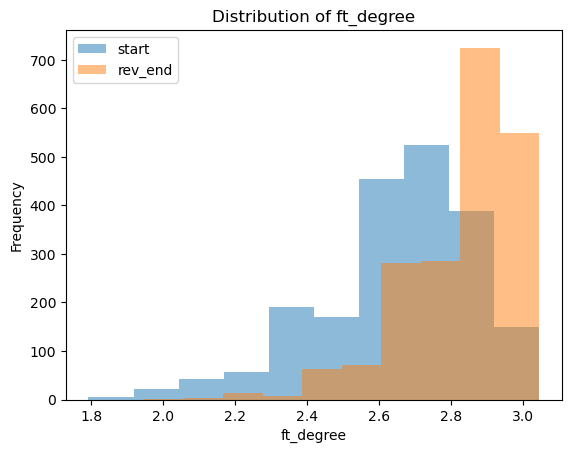

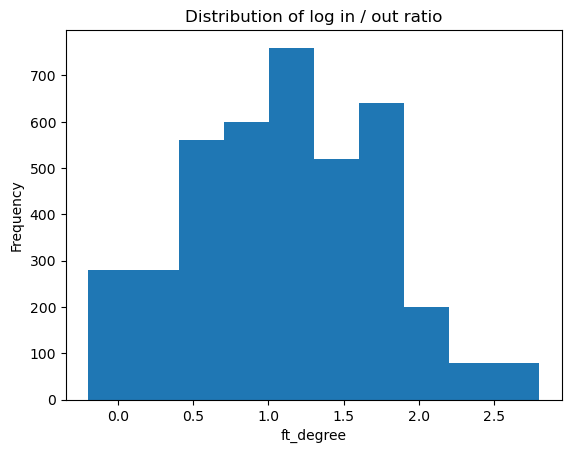

start


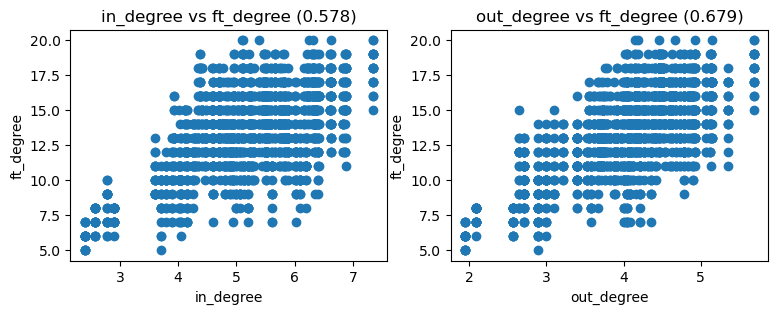

is ft degree differently correlated with in degree than with out degree
r12=0.578, r13=0.679, r23=0.754
Z=-7.88371, p=0.00000
rev_end


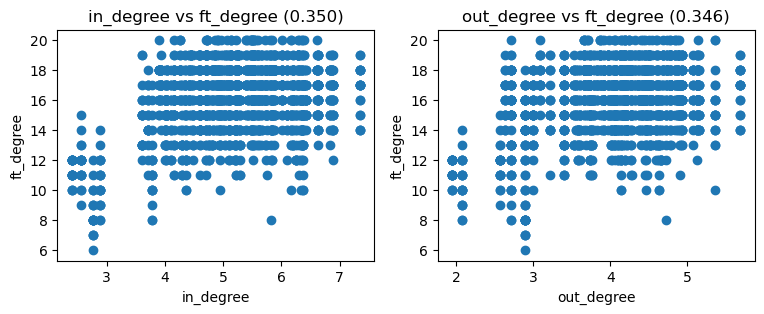

is ft degree differently correlated with in degree than with out degree
r12=0.350, r13=0.346, r23=0.754
Z=0.21508, p=0.82970


In [62]:
# 1. Distributions of each degree column
for col in ["in_degree", "out_degree", "ft_degree"]:
    plt.figure()
    if col == "ft_degree":
        plt.hist(
            np.log(1 + all_tree_df[all_tree_df.type == "start"][col].dropna()),
            alpha=0.5,
            label="start",
        )
        plt.hist(
            np.log(1 + all_tree_df[all_tree_df.type == "rev_end"][col].dropna()),
            alpha=0.5,
            label="rev_end",
        )
        plt.legend()
    else:
        plt.hist(np.log(1 + all_tree_df[col].dropna()))
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

plt.figure()
plt.hist(all_tree_df["log_in_out"])
plt.title(f"Distribution of log in / out ratio")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()


# 2. Compare degrees: scatter vs ft_degree
for t in all_tree_df.type.unique():
    this_df = all_tree_df[all_tree_df.type == t]
    print(t)

    fig, axes = plt.subplots(1, 2, figsize=(9, 3))

    for i, col in enumerate(["in_degree", "out_degree"]):
        axes[i].scatter(np.log(1 + this_df[col]), this_df["ft_degree"])
        axes[i].set_title(
            f"{col} vs ft_degree ({pearsonr(np.log(1 + this_df[col]), this_df['ft_degree'])[0]:.3f})"
        )
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("ft_degree")
    plt.show()
    r13, _ = pearsonr(np.log(1 + this_df["out_degree"]), this_df["ft_degree"])
    r12, _ = pearsonr(np.log(1 + this_df["in_degree"]), this_df["ft_degree"])
    r23, _ = pearsonr(
        np.log(1 + this_df["in_degree"]), np.log(1 + this_df["out_degree"])
    )

    # Testing: is r12 < r13? (i.e. is x2= zipf_frequencies LESS correlated with accuracies than x3 = betweenness_centralities?)
    print("is ft degree differently correlated with in degree than with out degree")
    z, p = steiger_z_test(
        r12, r13, r23, n=len(wikispeedia_counts), alternative="two-sided"
    )
    print(f"r12={r12:.3f}, r13={r13:.3f}, r23={r23:.3f}")
    print(f"Z={z:0.5f}, p={p:0.5f}")

In [70]:
topk = 10

print(
    "by in degree",
    [
        x[0]
        for x in all_tree_df[all_tree_df.type == "start"]
        .sort_values("in_degree", ascending=False)
        .drop_duplicates(subset="node")
        .head(topk)["node"]
        .tolist()
    ],
)
print(
    "by in degree (low)",
    [
        x[0]
        for x in all_tree_df[all_tree_df.type == "start"]
        .sort_values("in_degree", ascending=True)
        .drop_duplicates(subset="node")
        .head(topk)["node"]
        .tolist()
    ],
)
print(
    "by out degree",
    [
        x[0]
        for x in all_tree_df[all_tree_df.type == "start"]
        .sort_values("out_degree", ascending=False)
        .drop_duplicates(subset="node")
        .head(topk)["node"]
        .tolist()
    ],
)
print(
    "by out degree (low)",
    [
        x[0]
        for x in all_tree_df[all_tree_df.type == "start"]
        .sort_values("out_degree", ascending=True)
        .drop_duplicates(subset="node")
        .head(topk)["node"]
        .tolist()
    ],
)
print(
    "by in/out ratio (high)",
    [
        x[0]
        for x in all_tree_df[all_tree_df.type == "start"]
        .sort_values("log_in_out", ascending=False)
        .drop_duplicates(subset="node")
        .head(topk)["node"]
        .tolist()
    ],
)
print(
    "by in/out ratio (low)",
    [
        x[0]
        for x in all_tree_df[all_tree_df.type == "start"]
        .sort_values("log_in_out", ascending=True)
        .drop_duplicates(subset="node")
        .head(topk)["node"]
        .tolist()
    ],
)

print(
    "by start ft degree",
    [
        x[0]
        for x in all_tree_df[all_tree_df.type == "start"]
        .sort_values("ft_degree", ascending=False)
        .drop_duplicates(subset="node")
        .head(topk)["node"]
        .tolist()
    ],
)
print(
    "by start ft degree (low)",
    [
        x[0]
        for x in all_tree_df[all_tree_df.type == "start"]
        .sort_values("ft_degree", ascending=True)
        .drop_duplicates(subset="node")
        .head(topk)["node"]
        .tolist()
    ],
)
print(
    "by rev_end ft degree",
    [
        x[0]
        for x in all_tree_df[all_tree_df.type == "rev_end"]
        .sort_values("ft_degree", ascending=False)
        .drop_duplicates(subset="node")
        .head(topk)["node"]
        .tolist()
    ],
)
print(
    "by rev_end ft degree (low)",
    [
        x[0]
        for x in all_tree_df[all_tree_df.type == "rev_end"]
        .sort_values("ft_degree", ascending=True)
        .drop_duplicates(subset="node")
        .head(topk)["node"]
        .tolist()
    ],
)

by in degree ['United_States', 'United_Kingdom', 'France', 'Europe', 'England', 'World_War_II', 'Germany', 'India', 'English_language', 'London']
by in degree (low) ['Batman', 'Zebra', 'Pyramid', 'Bean', 'Communication', 'Computer_science', 'Telephone', 'Electronics', 'Organism', 'Brain']
by out degree ['United_States', 'Africa', 'England', 'Germany', 'United_Kingdom', '19th_century', 'Europe', 'Human', 'Asia', 'Periodic_table']
by out degree (low) ['Batman', 'Bean', 'Zebra', 'Fish', 'Telephone', 'Electronics', 'Communication', 'Theatre', 'Pyramid', 'Computer_science']
by in/out ratio (high) ['Animal', 'Latin', 'France', 'Fish', 'Canada', 'India', 'Television', 'Film', 'Christianity', 'Australia']
by in/out ratio (low) ['Periodic_table', 'Pyramid', 'Zebra', 'Brain', 'Dinosaur', 'British_Empire', 'Organism', 'Continent', 'Physics', 'Human']
by start ft degree ['Italy', 'United_States', 'Russia', 'England', 'Ancient_Greece', 'Norway', 'Human', 'India', 'London', 'People%27s_Republic_of_C

In [71]:
def tree_depth(graph, root=0):
    depths = nx.single_source_shortest_path_length(graph, root)
    return max(depths.values())


all_tree_df["num_nodes"] = all_tree_df.trees.apply(lambda x: x.number_of_nodes())
all_tree_df["depth"] = all_tree_df.trees.apply(tree_depth)
all_tree_df["diameter"] = all_tree_df.trees.apply(nx.diameter)
all_tree_df["num_leaves"] = all_tree_df.trees.apply(
    lambda graph: sum(1 for node in graph.nodes() if graph.degree(node) == 1)
)
all_tree_df["avg_bf"] = all_tree_df.trees.apply(
    lambda graph: np.mean([len(list(graph.neighbors(node))) for node in graph.nodes()])
)

all_tree_df

,node,trees,type,in_degree,out_degree,log_in_out,ft_degree,num_nodes,depth,diameter,num_leaves,avg_bf
0,"(United_States,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start,1551,294,1.660324,15,26,2,4,20,1.923077
1,"(United_States,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start,1551,294,1.660324,18,22,2,3,20,1.909091
2,"(United_States,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start,1551,294,1.660324,16,24,2,4,20,1.916667
3,"(United_States,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start,1551,294,1.660324,19,22,2,3,20,1.909091
4,"(United_States,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",start,1551,294,1.660324,18,23,2,4,20,1.913043
...,...,...,...,...,...,...,...,...,...,...,...,...
3995,"(Electricity,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",rev_end,109,38,1.036919,18,23,2,4,20,1.913043
3996,"(Electricity,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",rev_end,109,38,1.036919,17,23,2,4,20,1.913043
3997,"(Electricity,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",rev_end,109,38,1.036919,17,24,3,5,20,1.916667
3998,"(Electricity,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",rev_end,109,38,1.036919,17,23,2,4,20,1.913043


T-statistic: 34.3504, p=0.0000


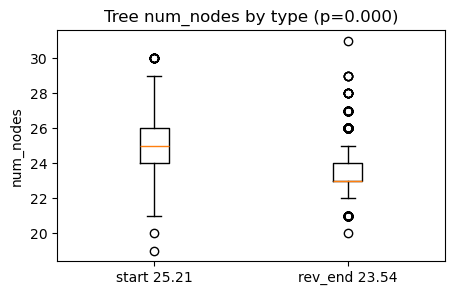

In [78]:
# Create figure with two subplots
fig, (ax1) = plt.subplots(1, 1, figsize=(5, 3))

groups = [
    all_tree_df[all_tree_df.type == t].num_nodes for t in all_tree_df.type.unique()
]
t_stat, p_val = stats.ttest_ind(groups[0], groups[1])
print(f"T-statistic: {t_stat:.4f}, p={p_val:.4f}")

labels = [
    x + f" {np.mean(groups[i]):.2f}" for i, x in enumerate(all_tree_df.type.unique())
]

ax1.boxplot(groups, labels=labels)
ax1.set_title(f"Tree num_nodes by type (p={p_val:.3f})")
ax1.set_ylabel("num_nodes")
plt.show()


T-statistic: 13.7620, p=0.0000


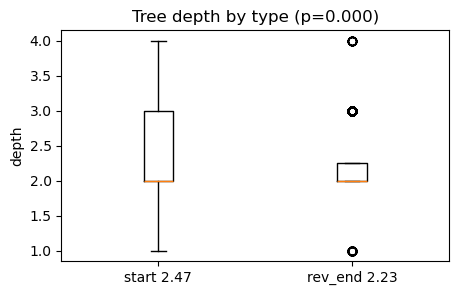

In [81]:
# Create figure with two subplots
fig, (ax1) = plt.subplots(1, 1, figsize=(5, 3))

groups = [all_tree_df[all_tree_df.type == t].depth for t in all_tree_df.type.unique()]
t_stat, p_val = stats.ttest_ind(groups[0], groups[1])
print(f"T-statistic: {t_stat:.4f}, p={p_val:.4f}")

labels = [
    x + f" {np.mean(groups[i]):.2f}" for i, x in enumerate(all_tree_df.type.unique())
]

ax1.boxplot(groups, labels=labels)
ax1.set_title(f"Tree depth by type (p={p_val:.3f})")
ax1.set_ylabel("depth")
plt.show()

T-statistic: 21.3833, p=0.0000


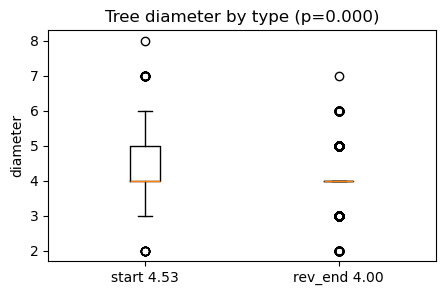

In [ ]:
# Create figure with two subplots
fig, (ax1) = plt.subplots(1, 1, figsize=(5, 3))

groups = [
    all_tree_df[all_tree_df.type == t].diameter for t in all_tree_df.type.unique()
]
t_stat, p_val = stats.ttest_ind(groups[0], groups[1])
print(f"T-statistic: {t_stat:.4f}, p={p_val:.4f}")

labels = [
    x + f" {np.mean(groups[i]):.2f}" for i, x in enumerate(all_tree_df.type.unique())
]

ax1.boxplot(groups, labels=labels)
ax1.set_title(f"Tree diameter by type (p={p_val:.3f})")
ax1.set_ylabel("diameter")
plt.show()

T-statistic: -4.2908, p=0.0000


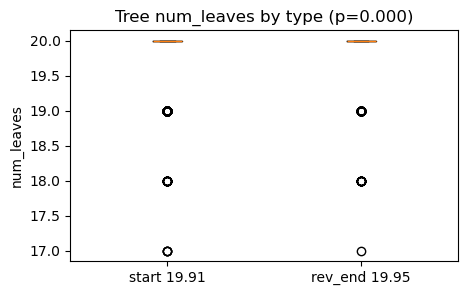

In [83]:
# Create figure with two subplots
fig, (ax1) = plt.subplots(1, 1, figsize=(5, 3))

groups = [
    all_tree_df[all_tree_df.type == t].num_leaves for t in all_tree_df.type.unique()
]
t_stat, p_val = stats.ttest_ind(groups[0], groups[1])
print(f"T-statistic: {t_stat:.4f}, p={p_val:.4f}")

labels = [
    x + f" {np.mean(groups[i]):.2f}" for i, x in enumerate(all_tree_df.type.unique())
]

ax1.boxplot(groups, labels=labels)
ax1.set_title(f"Tree num_leaves by type (p={p_val:.3f})")
ax1.set_ylabel("num_leaves")
plt.show()

T-statistic: 34.3859, p=0.0000


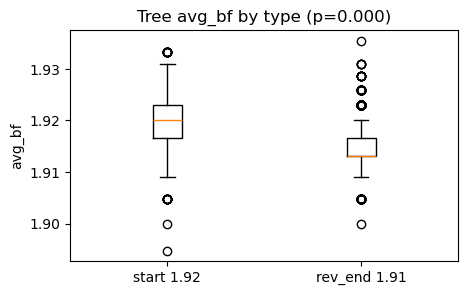

In [84]:
# Create figure with two subplots
fig, (ax1) = plt.subplots(1, 1, figsize=(5, 3))

groups = [all_tree_df[all_tree_df.type == t].avg_bf for t in all_tree_df.type.unique()]
t_stat, p_val = stats.ttest_ind(groups[0], groups[1])
print(f"T-statistic: {t_stat:.4f}, p={p_val:.4f}")

labels = [
    x + f" {np.mean(groups[i]):.2f}" for i, x in enumerate(all_tree_df.type.unique())
]

ax1.boxplot(groups, labels=labels)
ax1.set_title(f"Tree avg_bf by type (p={p_val:.3f})")
ax1.set_ylabel("avg_bf")
plt.show()

Four focuses:

* semantics
* generality
* centrality
* before/after zoom in (maybe look at switch points)

### Semantics

Q: do different semantic groups of nodes have different looking Flow Trees (eg, art v science)?

In [86]:
# To start, let's use wiki-defined categories
category_dict = {}
for node in most_common_nodes:
    # if node == "Pikachu":
    #     # for whatever reason Pikachu doesn't exist
    #     category_dict[node] = "Everyday_life"
    # else:
    category1 = categories_df.loc[categories_df["article"] == node, "category1"]
    category_dict[node] = category1.iloc[0]

all_tree_df["category"] = all_tree_df.node.apply(lambda x: category_dict[x[0]])

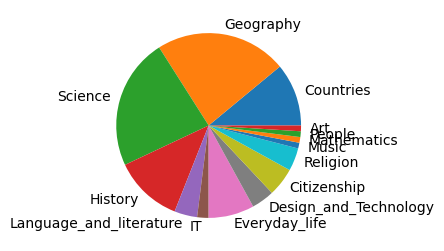

In [87]:
fig, (ax1) = plt.subplots(1, 1, figsize=(8, 3))
ax1.pie(
    [
        len(all_tree_df[all_tree_df.category == cat])
        for cat in all_tree_df.category.unique()
    ],
    labels=all_tree_df.category.unique(),
)
plt.xticks(rotation=90)
plt.show()

In [88]:
for cat in set(all_tree_df.category.unique()):
    print(cat, len(all_tree_df[all_tree_df.category == cat]))

Citizenship 200
Science 920
Geography 920
Everyday_life 320
People 40
Mathematics 40
Language_and_literature 160
Countries 440
Music 40
IT 80
Design_and_Technology 160
History 480
Art 40
Religion 160


In [89]:
start_tree_df = all_tree_df[all_tree_df.type == "start"]
rev_end_tree_df = all_tree_df[all_tree_df.type == "rev_end"]

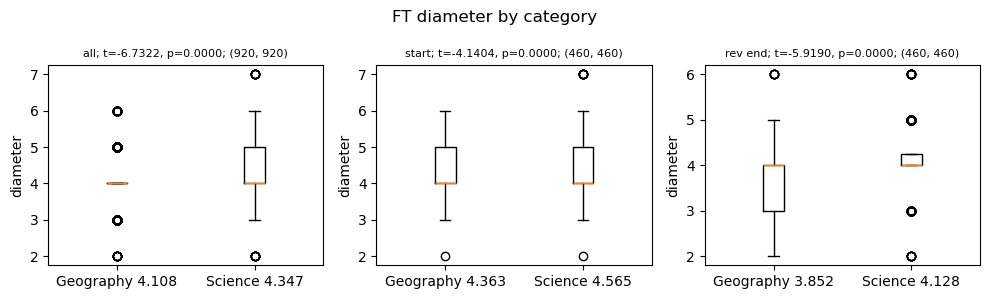

In [95]:
# Create figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 3))

# cats_to_compare = ["Science", "Everyday_life"]
cats_to_compare = ["Geography", "Science"]

groups = [all_tree_df[all_tree_df.category == c].diameter for c in cats_to_compare]
t_stat, p_val = stats.ttest_ind(groups[0], groups[1])
labels = [x + f" {np.mean(groups[i]):.3f}" for i, x in enumerate(cats_to_compare)]
ax1.boxplot(groups, labels=labels)
ax1.set_title(
    f"all; t={t_stat:.4f}, p={p_val:.4f}; {(len(groups[0]), len(groups[1]))}",
    fontsize=8,
)
ax1.set_ylabel("diameter")

groups = [start_tree_df[start_tree_df.category == c].diameter for c in cats_to_compare]
t_stat, p_val = stats.ttest_ind(groups[0], groups[1])
labels = [x + f" {np.mean(groups[i]):.3f}" for i, x in enumerate(cats_to_compare)]
ax2.boxplot(groups, labels=labels)
ax2.set_title(
    f"start; t={t_stat:.4f}, p={p_val:.4f}; {(len(groups[0]), len(groups[1]))}",
    fontsize=8,
)
ax2.set_ylabel("diameter")

groups = [
    rev_end_tree_df[rev_end_tree_df.category == c].diameter for c in cats_to_compare
]
t_stat, p_val = stats.ttest_ind(groups[0], groups[1])
labels = [x + f" {np.mean(groups[i]):.3f}" for i, x in enumerate(cats_to_compare)]
ax3.boxplot(groups, labels=labels)
ax3.set_title(
    f"rev end; t={t_stat:.4f}, p={p_val:.4f}; {(len(groups[0]), len(groups[1]))}",
    fontsize=8,
)
ax3.set_ylabel("diameter")

fig.suptitle("FT diameter by category")
plt.tight_layout()
plt.show()

In [ ]:
# Another way to do this is to cluster using an LM
sent_embeddings = [
    np.array(embed(node[0].replace("_", " "))).squeeze() for node in all_tree_df.node
]
print(sent_embeddings)

In [98]:
from sklearn.cluster import KMeans

k_clusters = 4
kmeans = KMeans(n_clusters=k_clusters, random_state=0, n_init="auto").fit(
    sent_embeddings
)
kmeans.labels_


array([1, 1, 1, ..., 3, 3, 3], dtype=int32)

In [99]:
all_tree_df["kmeans_sent_embed"] = kmeans.labels_

print([x[0] for x in all_tree_df[(all_tree_df.kmeans_sent_embed == 0)].node.unique()])
print([x[0] for x in all_tree_df[(all_tree_df.kmeans_sent_embed == 1)].node.unique()])


['Earth', 'Earth', 'Earth', 'Earth', 'Earth', 'Earth', 'Earth', 'Earth', 'Earth', 'Earth', 'Earth', 'Earth', 'Earth', 'Earth', 'Earth', 'Earth', 'Earth', 'Earth', 'Earth', 'Earth', 'Animal', 'Animal', 'Animal', 'Animal', 'Animal', 'Animal', 'Animal', 'Animal', 'Animal', 'Animal', 'Animal', 'Animal', 'Animal', 'Animal', 'Animal', 'Animal', 'Animal', 'Animal', 'Animal', 'Animal', 'Mammal', 'Mammal', 'Mammal', 'Mammal', 'Mammal', 'Mammal', 'Mammal', 'Mammal', 'Mammal', 'Mammal', 'Mammal', 'Mammal', 'Mammal', 'Mammal', 'Mammal', 'Mammal', 'Mammal', 'Mammal', 'Mammal', 'Mammal', 'Human', 'Human', 'Human', 'Human', 'Human', 'Human', 'Human', 'Human', 'Human', 'Human', 'Human', 'Human', 'Human', 'Human', 'Human', 'Human', 'Human', 'Human', 'Human', 'Human', 'Brain', 'Brain', 'Brain', 'Brain', 'Brain', 'Brain', 'Brain', 'Brain', 'Brain', 'Brain', 'Brain', 'Brain', 'Brain', 'Brain', 'Brain', 'Brain', 'Brain', 'Brain', 'Brain', 'Brain', 'Computer', 'Computer', 'Computer', 'Computer', 'Computer',

In [266]:
# entropy is -sum(p_i * log p_i)
tottot = len(all_tree_df)
avg_entropy = 0
for cat in set(all_tree_df.category.unique()):
    entropy = 0
    tot = len(all_tree_df[all_tree_df.category == cat])
    counts = []
    for lab in all_tree_df.kmeans_sent_embed.unique():
        lab_count = len(
            all_tree_df[
                (all_tree_df.category == cat) & (all_tree_df.kmeans_sent_embed == lab)
            ]
        )
        counts.append(lab_count)
        prob = lab_count / tot
        if prob != 0:
            entropy -= prob * np.log(prob) / np.log(k_clusters)

    print(cat, tot, entropy, counts)
    avg_entropy += entropy * (tot / tottot)
avg_entropy

People 12 0.0 [0, 12]
Music 4 1.0 [2, 2]
Language_and_literature 8 0.8112781244591328 [2, 6]
Art 2 0.0 [2, 0]
Everyday_life 37 0.9352691398683567 [24, 13]
Science 53 0.5631028237513912 [46, 7]
Design_and_Technology 8 0.0 [8, 0]
Citizenship 2 0.0 [2, 0]
Religion 10 0.0 [10, 0]
Countries 7 0.5916727785823274 [6, 1]
History 6 0.9182958340544896 [2, 4]
Business_Studies 4 0.0 [4, 0]
IT 13 0.9957274520849257 [6, 7]
Mathematics 2 0.0 [2, 0]
Geography 28 0.3712323266408757 [26, 2]


0.5506636699340703

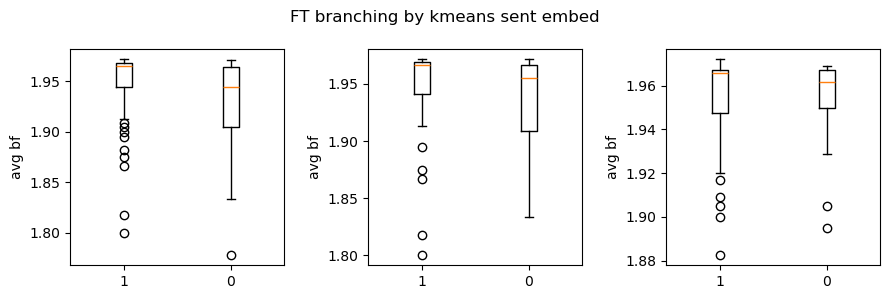

In [267]:
# Create figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(9, 3))

cats_to_compare = all_tree_df.kmeans_sent_embed.unique()

groups = [
    all_tree_df[all_tree_df.kmeans_sent_embed == c].avg_bf for c in cats_to_compare
]
# t_stat, p_val = stats.ttest_ind(groups[0], groups[1])
ax1.boxplot(groups, labels=cats_to_compare)
# ax1.set_title(f"all; t={t_stat:.4f}, p={p_val:.4f}; {(len(groups[0]), len(groups[1]))}", fontsize=8)
ax1.set_ylabel("avg bf")

groups = [
    start_tree_df[start_tree_df.kmeans_sent_embed == c].avg_bf for c in cats_to_compare
]
# t_stat, p_val = stats.ttest_ind(groups[0], groups[1])
ax2.boxplot(groups, labels=cats_to_compare)
# ax2.set_title(f"start; t={t_stat:.4f}, p={p_val:.4f}; {(len(groups[0]), len(groups[1]))}", fontsize=8)
ax2.set_ylabel("avg bf")

groups = [
    rev_end_tree_df[rev_end_tree_df.kmeans_sent_embed == c].avg_bf
    for c in cats_to_compare
]
# t_stat, p_val = stats.ttest_ind(groups[0], groups[1])
ax3.boxplot(groups, labels=cats_to_compare)
# ax3.set_title(f"rev end; t={t_stat:.4f}, p={p_val:.4f}; {(len(groups[0]), len(groups[1]))}", fontsize=8)
ax3.set_ylabel("avg bf")

fig.suptitle("FT branching by kmeans sent embed")
plt.tight_layout()
plt.show()

### Generality

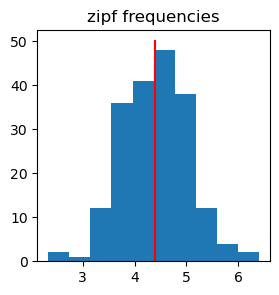

In [186]:
# can do semantic generality ~ word frequency
def topic_zipf(node):
    words = node.split("_")
    return np.mean([zipf_frequency(w, "en") for w in words])


all_tree_df["zipf_frequency"] = all_tree_df.node.apply(lambda x: topic_zipf(x[0]))
mean_zipf = all_tree_df["zipf_frequency"].mean()

fig, (ax1) = plt.subplots(1, 1, figsize=(3, 3))
ax1.hist(all_tree_df["zipf_frequency"])
ax1.plot([mean_zipf, mean_zipf], [0, 50], c="r")
ax1.set_title("zipf frequencies")
plt.show()

all_tree_df["zipf_group"] = all_tree_df.zipf_frequency.apply(lambda x: x > mean_zipf)

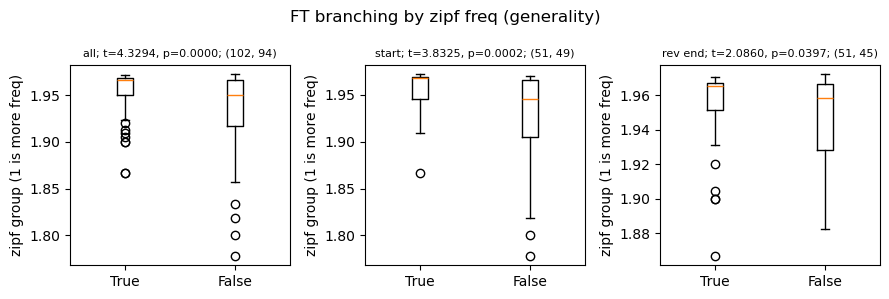

In [189]:
# Create figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(9, 3))

cats_to_compare = all_tree_df.zipf_group.unique()

groups = [all_tree_df[all_tree_df.zipf_group == c].avg_bf for c in cats_to_compare]
t_stat, p_val = stats.ttest_ind(groups[0], groups[1])
ax1.boxplot(groups, labels=cats_to_compare)
ax1.set_title(
    f"all; t={t_stat:.4f}, p={p_val:.4f}; {(len(groups[0]), len(groups[1]))}",
    fontsize=8,
)
ax1.set_ylabel("zipf group (1 is more freq)")

groups = [start_tree_df[start_tree_df.zipf_group == c].avg_bf for c in cats_to_compare]
t_stat, p_val = stats.ttest_ind(groups[0], groups[1])
ax2.boxplot(groups, labels=cats_to_compare)
ax2.set_title(
    f"start; t={t_stat:.4f}, p={p_val:.4f}; {(len(groups[0]), len(groups[1]))}",
    fontsize=8,
)
ax2.set_ylabel("zipf group (1 is more freq)")

groups = [
    rev_end_tree_df[rev_end_tree_df.zipf_group == c].avg_bf for c in cats_to_compare
]
t_stat, p_val = stats.ttest_ind(groups[0], groups[1])
ax3.boxplot(groups, labels=cats_to_compare)
ax3.set_title(
    f"rev end; t={t_stat:.4f}, p={p_val:.4f}; {(len(groups[0]), len(groups[1]))}",
    fontsize=8,
)
ax3.set_ylabel("zipf group (1 is more freq)")

fig.suptitle("FT branching by zipf freq (generality)")
plt.tight_layout()
plt.show()

### Centrality

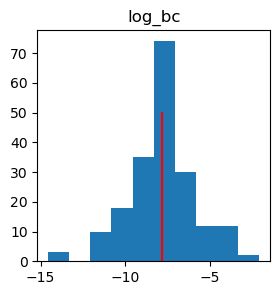

In [254]:
# also can do structural generality ~ centrality
all_tree_df["betweenness_centrality"] = all_tree_df.node.apply(
    lambda x: betweenness_centrality[x[0]]
)
all_tree_df["log_bc"] = all_tree_df.betweenness_centrality.apply(np.log)
mean_bc = all_tree_df["log_bc"].mean()

fig, (ax1) = plt.subplots(1, 1, figsize=(3, 3))
ax1.hist(all_tree_df["log_bc"])
ax1.plot([mean_bc, mean_bc], [0, 50], c="r")
ax1.set_title("log_bc")
plt.show()

all_tree_df["bc_group"] = all_tree_df.log_bc.apply(lambda x: x > mean_bc)

start_tree_df = all_tree_df[all_tree_df.type == "start"]
rev_end_tree_df = all_tree_df[all_tree_df.type == "rev_end"]

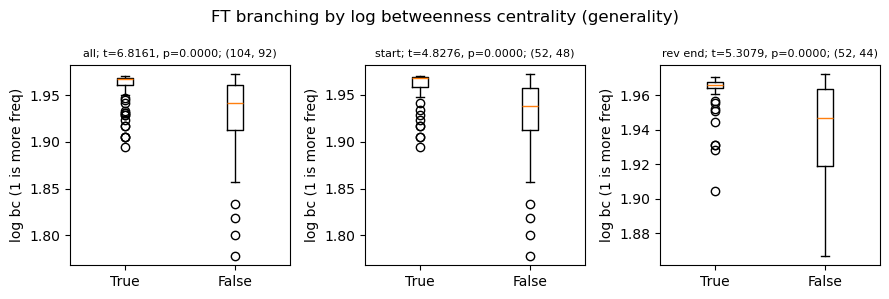

In [255]:
# Create figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(9, 3))

cats_to_compare = all_tree_df.bc_group.unique()

groups = [all_tree_df[all_tree_df.bc_group == c].avg_bf for c in cats_to_compare]
t_stat, p_val = stats.ttest_ind(groups[0], groups[1])
ax1.boxplot(groups, labels=cats_to_compare)
ax1.set_title(
    f"all; t={t_stat:.4f}, p={p_val:.4f}; {(len(groups[0]), len(groups[1]))}",
    fontsize=8,
)
ax1.set_ylabel("log bc (1 is more freq)")

groups = [start_tree_df[start_tree_df.bc_group == c].avg_bf for c in cats_to_compare]
t_stat, p_val = stats.ttest_ind(groups[0], groups[1])
ax2.boxplot(groups, labels=cats_to_compare)
ax2.set_title(
    f"start; t={t_stat:.4f}, p={p_val:.4f}; {(len(groups[0]), len(groups[1]))}",
    fontsize=8,
)
ax2.set_ylabel("log bc (1 is more freq)")

groups = [
    rev_end_tree_df[rev_end_tree_df.bc_group == c].avg_bf for c in cats_to_compare
]
t_stat, p_val = stats.ttest_ind(groups[0], groups[1])
ax3.boxplot(groups, labels=cats_to_compare)
ax3.set_title(
    f"rev end; t={t_stat:.4f}, p={p_val:.4f}; {(len(groups[0]), len(groups[1]))}",
    fontsize=8,
)
ax3.set_ylabel("log bc (1 is more freq)")

fig.suptitle("FT branching by log betweenness centrality (generality)")
plt.tight_layout()
plt.show()

in vs. out degree

### Zoom in

In [304]:
# see if we can identify zoom out v zoom in

# first only successful
successful_df = trajs_df[trajs_df.finished]

example_trajs = successful_df.traj

outliers = set([])

plottable_freqs = []
plottable_freq_diffs = []
plottable_bcs = []
for example_traj in example_trajs:
    if len(example_traj) < 3:
        continue
    freqs = []
    freq_diffs = []
    bcs = []
    for i in range(len(example_traj)):
        freqs.append(topic_zipf(example_traj[i]))
        if i < len(example_traj) - 1:
            freq_diffs.append(
                topic_zipf(example_traj[i]) - topic_zipf(example_traj[i + 1])
            )

        bcs.append(betweenness_centrality.get(example_traj[i], 0))

        if bcs[-1] - bcs[0] > 0.02:
            outliers.add(example_traj[i])

    plottable_freqs.append(
        (
            [x / (len(freqs) - 1) for x in range(len(freqs))],
            [f - freqs[0] for f in freqs],
        )
    )
    plottable_freq_diffs.append(
        ([x / (len(freq_diffs) - 1) for x in range(len(freq_diffs))], freq_diffs)
    )
    plottable_bcs.append(
        (
            [x / (len(bcs) - 1) for x in range(len(bcs))],
            [(f - bcs[0]) / (np.max(bcs) - bcs[0]) for f in bcs],
        )
    )

print(outliers)


/var/folders/24/lp6939qs6f1d149198s_3mv40000gn/T/ipykernel_1099/3211311167.py:30: RuntimeWarning: invalid value encountered in scalar divide
  plottable_bcs.append(([x/(len(bcs)-1) for x in range(len(bcs))], [(f - bcs[0]) / (np.max(bcs) - bcs[0]) for f in bcs]))
/var/folders/24/lp6939qs6f1d149198s_3mv40000gn/T/ipykernel_1099/3211311167.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  plottable_bcs.append(([x/(len(bcs)-1) for x in range(len(bcs))], [(f - bcs[0]) / (np.max(bcs) - bcs[0]) for f in bcs]))


{'Europe', 'United_States', 'France', 'English_language', 'United_Kingdom', 'World_War_II', 'England', 'Germany'}


In [320]:
def cat_peaks(x):
    peak = np.max(x)

    peak_hit = False
    for xx in x:
        if not peak_hit and xx == peak:
            peak_hit = True
        elif peak_hit and xx >= peak:
            return "ManyPeak"

    if x[-1] == peak:
        return "EndPeak"

    return "OnePeak"


nodess = []
bbcs = []
peak_classes = []
for example_traj in example_trajs:
    if len(example_traj) < 3:
        continue
    bcs = []
    for i in range(len(example_traj)):
        bcs.append(betweenness_centrality.get(example_traj[i], 0))

    peak_classes.append(cat_peaks(bcs))

    bbcs.append(bcs)
    nodess.append(example_traj)


print(peak_classes)
print(
    peak_classes.count("OnePeak") / len(peak_classes),
    peak_classes.count("ManyPeak") / len(peak_classes),
    peak_classes.count("EndPeak") / len(peak_classes),
)

['OnePeak', 'OnePeak', 'OnePeak', 'EndPeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'ManyPeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'ManyPeak', 'OnePeak', 'EndPeak', 'EndPeak', 'ManyPeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'EndPeak', 'EndPeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'EndPeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'ManyPeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'EndPeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OnePeak', 'OneP

In [322]:
one_peaks = [
    plottable_bcs[i] for i in range(len(peak_classes)) if peak_classes[i] == "OnePeak"
]
many_peaks = [
    plottable_bcs[i] for i in range(len(peak_classes)) if peak_classes[i] == "ManyPeak"
]
end_peaks = [
    plottable_bcs[i] for i in range(len(peak_classes)) if peak_classes[i] == "EndPeak"
]

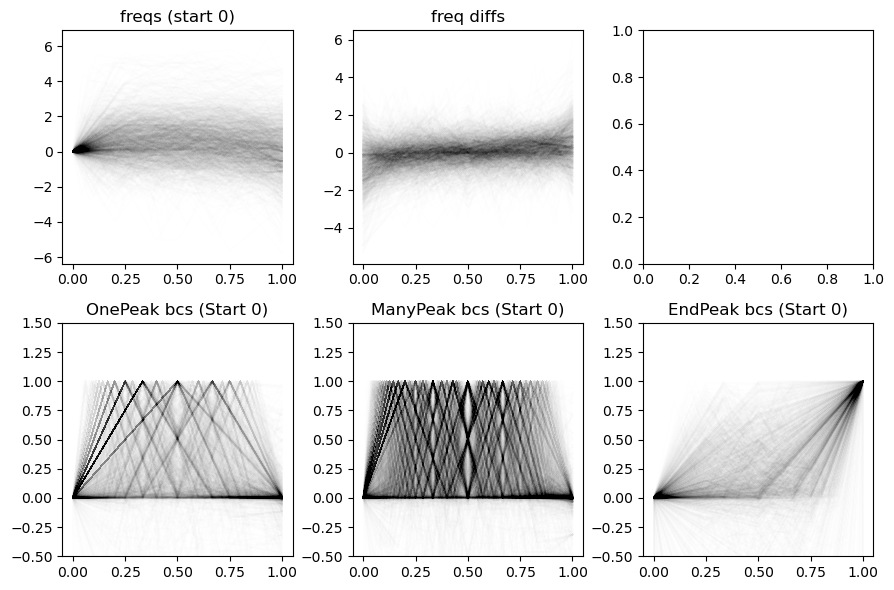

In [323]:
fig, ((ax1, ax2, _), (ax3, ax4, ax5)) = plt.subplots(2, 3, figsize=(9, 6))


for xs, ys in random.sample(plottable_freqs, 2000):
    ax1.plot(xs, ys, c="black", alpha=0.005)
    ax1.set_title("freqs (start 0)")

for xs, ys in random.sample(plottable_freq_diffs, 2000):
    ax2.plot(xs, ys, c="black", alpha=0.005)
    ax2.set_title("freq diffs")

for xs, ys in random.sample(one_peaks, 2000):
    ax3.plot(xs, ys, c="black", alpha=0.005)
    ax3.set_title("OnePeak bcs (Start 0)")
    ax3.set_ylim(-0.5, 1.5)

for xs, ys in many_peaks:  # random.sample(end_peaks, 2000):
    ax4.plot(xs, ys, c="black", alpha=0.005)
    ax4.set_title("ManyPeak bcs (Start 0)")
    ax4.set_ylim(-0.5, 1.5)

for xs, ys in end_peaks:  # random.sample(end_peaks, 2000):
    ax5.plot(xs, ys, c="black", alpha=0.005)
    ax5.set_title("EndPeak bcs (Start 0)")
    ax5.set_ylim(-0.5, 1.5)

plt.tight_layout()
plt.show()